In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import math
from datetime import datetime, timedelta
from difflib import SequenceMatcher
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
import os
from pathlib import Path
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import sys
import scipy
import sklearn
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import OneHotEncoder
from lifelines.plotting import add_at_risk_counts
from lifelines.statistics import pairwise_logrank_test
import seaborn as sns
import numpy as np
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from lifelines import CoxTimeVaryingFitter
from lifelines import CoxPHFitter
import warnings
from statsmodels.discrete.conditional_models import ConditionalLogit
from preproces_prod3 import *
from matching_case_control import call_data, flexible_matching, summary_inicial, comparar_medias_test,analyze_vrs_data,  integer_programming_matching_gurobi,  match_nn_max_dist_weigths
from patsy import dmatrices
from IPython.core.display import display
import gspread
from oauth2client.service_account import ServiceAccountCredentials
from gspread_dataframe import set_with_dataframe
warnings.filterwarnings("ignore")
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

path_actual = Path.cwd()
path_data = path_actual.parent / 'Data'

In [203]:
import gspread
from oauth2client.service_account import ServiceAccountCredentials

# Configurar las credenciales
scope = ["https://spreadsheets.google.com/feeds", "https://www.googleapis.com/auth/spreadsheets",
         "https://www.googleapis.com/auth/drive.file", "https://www.googleapis.com/auth/drive"]

creds = ServiceAccountCredentials.from_json_keyfile_name(path_actual.parent.parent/"credencials.json", scope)
client = gspread.authorize(creds)

# Abrir la hoja de cálculo
spreadsheet = client.open("Efecto_NIRSE")  # Reemplaza con el nombre de tu hoja de cálculo
sheet = spreadsheet.sheet1 

In [204]:
def upload_results_to_sheet(spreadsheet, df, sheet_name):
    """
    Sube un DataFrame a una hoja específica en un archivo de Google Sheets.
    
    Args:
        spreadsheet: Objeto de la hoja de cálculo (spreadsheet) abierta con gspread.
        df: DataFrame a subir.
        sheet_name: Nombre de la hoja dentro del archivo de Google Sheets.
    """
    try:
        # Abrir o crear la hoja especificada
        try:
            worksheet = spreadsheet.worksheet(sheet_name)
        except gspread.exceptions.WorksheetNotFound:
            worksheet = spreadsheet.add_worksheet(title=sheet_name, rows=100, cols=20)

        # Limpiar la hoja antes de cargar nuevos datos
        worksheet.clear()

        # Subir el DataFrame a la hoja
        set_with_dataframe(worksheet, df)

        print(f"Datos subidos exitosamente a la hoja '{sheet_name}'")
    except Exception as e:
        print(f"Error al subir los datos: {e}")

In [3]:
df_vrs, df_upc, df_vrs_tilweek, df_upc_tilweek ,df_muertos, df_precampaña = call_data_cox(path_data/'NAC_RNI_EGRESOS_ENTREGA_ISCI_18_11_2024_encr.csv', 34, group_age=True,weeks_inm=False)

n_rows_inicial= 183275
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 183275
Datos perdidos por muertes:  1224
Datos perdidos por filtro semanas y peso:  1749
Droped intersex: 9
Reemplazos n/a net 7 days inmunizado:  24
Datos perdidos por fecha ingreso menor a fecha nacimiento: 17
Datos perdidos por edad madr

In [4]:
run_raro='bed99009d64eb031ead9235037fc95761d6f334e1d0bc27be4349f1734ca5b2f'
df_vrs = df_vrs.query('RUN!=@run_raro')
df_upc = df_upc.query('RUN!=@run_raro')

In [ ]:
df_vrs_post = post_proces_df_cox(df_vrs)
df_upc_post = post_proces_df_cox(df_upc)

No hay info de probeza de: []
No hay info de probeza de: []


In [21]:
df_vrs_post, vrs_preabril, one_hot_weekBI, one_hot_mesBI, one_hot_macr, one_hot_regions = df_vrs_post
df_upc_post, upc_preabril, one_hot_weekBI2, one_hot_mesBI2, one_hot_macr2, one_hot_regions2 = df_upc_post

In [ ]:
df_vrs_post.to_csv(path_data/'df_vrs_s34_1811_all_meses.csv',index=False)
df_upc_post.to_csv(path_data/'df_upc_s34_1811_all_meses.csv',index=False)

In [3]:
df_vrs_post = pd.read_csv(path_data/'df_vrs_s34_1811_all_meses.csv')
df_upc_post = pd.read_csv(path_data/'df_upc_s34_1811_all_meses.csv')

In [57]:
covs = ['start', 'inmunizado', 'stop', 'RUN', 'event_vrs','sexo','region','group_age','muy_prematuro','is_poor','is_rural']
cox_todo_chile = cox_return(df_vrs_post, covs=covs, prematuros=False)

In [73]:
cox_todo_chile.reset_index().query('covariate=="inmunizado"')

,covariate,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
0,inmunizado,-1.353,0.742,0.081,-1.513,-1.194,0.697,0.78,0.0


In [25]:
covs = ['start', 'inmunizado', 'stop', 'RUN', 'event_vrs','sexo','region','group_age','muy_prematuro','is_poor','is_rural']
cox(df_vrs_post,covs,prematuros=True)

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-0.547,0.421,0.252,-1.042,-0.053,0.051,0.647,0.030
sexo,0.560,-0.751,0.198,0.172,0.948,-1.581,-0.187,0.005
muy_prematuro,0.590,-0.803,0.310,-0.018,1.197,-2.310,0.017,0.057
is_poor,0.093,-0.098,0.205,-0.309,0.496,-0.641,0.266,0.649
is_rural,-0.443,0.358,0.617,-1.652,0.767,-1.153,0.808,0.473


In [26]:
covs = ['start', 'inmunizado', 'stop', 'RUN', 'event_upc','sexo','region','group_age','muy_prematuro','is_poor','is_rural']
cox(df_upc_post,covs,prematuros=False)

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.582,0.794,0.171,-1.918,-1.246,0.712,0.853,0.000
sexo,0.661,-0.937,0.155,0.358,0.964,-1.623,-0.431,0.000
muy_prematuro,0.874,-1.395,0.417,0.057,1.690,-4.422,-0.058,0.036
is_poor,-0.075,0.072,0.161,-0.391,0.241,-0.273,0.324,0.642
is_rural,-0.057,0.056,0.406,-0.853,0.738,-1.092,0.574,0.888


In [27]:
covs = ['start', 'inmunizado', 'stop', 'RUN', 'event_upc','sexo','region','group_age','muy_prematuro','is_poor','is_rural']
cox(df_upc_post,covs,prematuros=True)

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.227,0.707,0.455,-2.119,-0.335,0.284,0.880,0.007
sexo,0.675,-0.964,0.397,-0.104,1.454,-3.279,0.099,0.089
muy_prematuro,0.290,-0.336,0.737,-1.155,1.734,-4.663,0.685,0.694
is_poor,0.011,-0.011,0.417,-0.807,0.829,-1.292,0.554,0.978
is_rural,-0.438,0.355,1.075,-2.545,1.669,-4.308,0.922,0.684


In [47]:
chile_chico = ['METROPOLITANA','VALPARAISO','LOS LAGOS',"O'HIGGINS",'ARICA Y PARINACOTA','TARAPACA'] #MAULE
df_vrs_post_chico = df_vrs_post.query('region.isin(@chile_chico)')
df_upc_post_chico = df_upc_post.query('region.isin(@chile_chico)')

In [48]:
covs = ['start', 'inmunizado', 'stop', 'RUN', 'event_vrs','sexo','region','group_age','muy_prematuro','is_poor','is_rural']
cox(df_vrs_post_chico, covs=covs, prematuros=False)

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.520,0.781,0.095,-1.705,-1.334,0.737,0.818,0.000
sexo,0.495,-0.640,0.083,0.331,0.658,-0.931,-0.393,0.000
muy_prematuro,1.131,-2.097,0.198,0.743,1.518,-3.562,-1.103,0.000
is_poor,0.286,-0.331,0.087,0.114,0.457,-0.579,-0.121,0.001
is_rural,-0.613,0.458,0.328,-1.255,0.029,-0.029,0.715,0.061


In [52]:
covs = ['start', 'inmunizado', 'stop', 'RUN', 'event_vrs','sexo','region','group_age']
cox(df_vrs_post_chico,covs,prematuros=True)

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-0.937,0.608,0.277,-1.479,-0.395,0.326,0.772,0.001
sexo,0.427,-0.533,0.223,-0.010,0.865,-1.374,0.010,0.055


In [53]:
covs = ['start', 'inmunizado', 'stop', 'RUN', 'event_upc','sexo','region','group_age','muy_prematuro']
cox(df_upc_post_chico,covs,prematuros=False)

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.681,0.814,0.194,-2.060,-1.301,0.728,0.873,0.000
sexo,0.682,-0.977,0.176,0.336,1.027,-1.793,-0.400,0.000
muy_prematuro,0.972,-1.644,0.456,0.078,1.867,-5.466,-0.081,0.033


In [54]:
covs = ['start', 'inmunizado', 'stop', 'RUN', 'event_upc','sexo','region','group_age']
cox(df_upc_post_chico,covs,prematuros=True)

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.320,0.733,0.494,-2.289,-0.351,0.296,0.899,0.008
sexo,0.817,-1.264,0.441,-0.047,1.681,-4.372,0.046,0.064


#### A iterar

In [76]:
df_vrs_post.Macrozona2.value_counts()

Macrozona2
Centro    474120
Sur        88033
Norte      64323
Name: count, dtype: int64

In [ ]:
covs = ['start', 'inmunizado', 'stop', 'RUN', 'event_vrs','sexo','region','group_age','muy_prematuro','is_poor','is_rural']

cox_todo_chile = cox_return(df_vrs_post, covs=covs, prematuros=False)

In [4]:
chile_1 = ['METROPOLITANA','VALPARAISO','LOS LAGOS',"O'HIGGINS",'ARICA Y PARINACOTA','TARAPACA'] #best_eff
chile_2 = ['METROPOLITANA','VALPARAISO','LOS LAGOS',"O'HIGGINS",'TARAPACA','MAULE','NUBLE','BIOBIO'] #best_p_v
chile_3 = ['METROPOLITANA','VALPARAISO','LOS LAGOS',"O'HIGGINS",'ARICA Y PARINACOTA','TARAPACA','MAULE','NUBLE','BIOBIO','LOS RIOS'] #all_acceptable
chile_entero = ['METROPOLITANA', 'ATACAMA', 'BIOBIO', 'COQUIMBO', 'NUBLE', 'VALPARAISO', 'TARAPACA', 'ANTOFAGASTA', 'LOS LAGOS', 'ARAUCANIA',
                'LOS RIOS', 'AISEN', "O'HIGGINS", 'MAULE', 'ARICA Y PARINACOTA','MAGALLANES Y ANTARTICA']

# Diccionarios para mapeos de macrozonas
region_to_macrozone_agencia = {
    "ARICA Y PARINACOTA": "Macrozona Norte",
    "TARAPACA": "Macrozona Norte",
    "ANTOFAGASTA": "Macrozona Norte",
    "ATACAMA": "Macrozona Norte",
    "COQUIMBO": "Macrozona Centro Norte",
    "VALPARAISO": "Macrozona Centro Norte",
    "METROPOLITANA": "Macrozona Centro Norte",
    "O'HIGGINS": "Macrozona Centro Norte",
    "MAULE": "Macrozona Centro Sur",
    "NUBLE": "Macrozona Centro Sur",
    "BIOBIO": "Macrozona Centro Sur",
    "ARAUCANIA": "Macrozona Centro Sur",
    "LOS RIOS": "Macrozona Sur",
    "LOS LAGOS": "Macrozona Sur",
    "AISEN": "Macrozona Austral",
    "MAGALLANES Y ANTARTICA": "Macrozona Austral"
}

region_to_macrozone_ciencia = {
    "ARICA Y PARINACOTA": "Macrozona Norte",
    "TARAPACA": "Macrozona Norte",
    "ANTOFAGASTA": "Macrozona Norte",
    "ATACAMA": "Macrozona Norte",
    "COQUIMBO": "Macrozona Centro",
    "VALPARAISO": "Macrozona Centro",
    "METROPOLITANA": "Region Metropolitana",
    "O'HIGGINS": "Macrozona Centro Sur",
    "MAULE": "Macrozona Centro Sur",
    "NUBLE": "Macrozona Centro Sur",
    "BIOBIO": "Macrozona Centro Sur",
    "ARAUCANIA": "Macrozona Sur",
    "LOS RIOS": "Macrozona Sur",
    "LOS LAGOS": "Macrozona Sur",
    "AISEN": "Macrozona Austral",
    "MAGALLANES Y ANTARTICA": "Macrozona Austral"
}

for df in [df_vrs_post,df_upc_post]:
    df["chile_chico_1"] = df["region"].apply(lambda x: 1 if x in chile_1 else 0)
    df["chile_chico_2"] = df["region"].apply(lambda x: 1 if x in chile_2 else 0)
    df["chile_chico_3"] = df["region"].apply(lambda x: 1 if x in chile_3 else 0)
    df["chile_entero"] = df["region"].apply(lambda x: 1 if x in chile_entero else 0)
    df["macrozona_v1"] = df["region"].map(region_to_macrozone_agencia)
    df["macrozona_v2"] = df["region"].map(region_to_macrozone_ciencia)

# Crear la lista de filtros
filtros = [
    "chile_chico_1 == 1",
    "chile_chico_2 == 1",
    "chile_chico_3 == 1",
    "chile_entero == 1"
    
]

# Agregar filtros por valores únicos de macrozona_v1
megazonas = df_vrs_post["Macrozona2"].dropna().unique()
filtros.extend([f"Macrozona2 == '{macro}'" for macro in megazonas])

# Agregar filtros por valores únicos de macrozona_v1
macrozonas_v1 = df_vrs_post["macrozona_v1"].dropna().unique()
filtros.extend([f"macrozona_v1 == '{macro}'" for macro in macrozonas_v1])

# Agregar filtros por valores únicos de macrozona_v2
macrozonas_v2 = df_vrs_post["macrozona_v2"].dropna().unique()
filtros.extend([f"macrozona_v2 == '{macro}'" for macro in macrozonas_v2])

# Imprimir los filtros generados
print("Filtros generados:")
print(filtros)

Filtros generados:
['chile_chico_1 == 1', 'chile_chico_2 == 1', 'chile_chico_3 == 1', 'chile_entero == 1', "Macrozona2 == 'Centro'", "Macrozona2 == 'Norte'", "Macrozona2 == 'Sur'", "macrozona_v1 == 'Macrozona Centro Norte'", "macrozona_v1 == 'Macrozona Norte'", "macrozona_v1 == 'Macrozona Centro Sur'", "macrozona_v1 == 'Macrozona Sur'", "macrozona_v1 == 'Macrozona Austral'", "macrozona_v2 == 'Region Metropolitana'", "macrozona_v2 == 'Macrozona Norte'", "macrozona_v2 == 'Macrozona Centro Sur'", "macrozona_v2 == 'Macrozona Centro'", "macrozona_v2 == 'Macrozona Sur'", "macrozona_v2 == 'Macrozona Austral'"]


In [158]:
results = []
covs_vrs = ['start', 'inmunizado', 'stop', 'RUN','sexo','event_vrs','region','group_age','muy_prematuro','is_poor','is_rural']
covs_upc = ['start', 'inmunizado', 'stop', 'RUN','sexo','event_upc','region','group_age','muy_prematuro','is_poor','is_rural']
for i, filtro in enumerate(filtros):
    for df_name, df in [("basica", df_vrs_post), ("UPC", df_upc_post)]:
        if df_name =='basica':
            covs = covs_vrs
        else:
            covs = covs_upc
        for prematuros_bool in [False, True]:
            
            # Aplicar el filtro al DataFrame
            df_filtrado = df.query(filtro)
            try:
            
                cox_resultado = cox_return(df_filtrado, covs=covs, prematuros=prematuros_bool).reset_index()
                effectiveness = cox_resultado.loc[cox_resultado['covariate'] == 'inmunizado', 'effectiveness'].values[0]
            except:
                effectiveness = 'error'

            # Guardar resultados en la lista
            results.append({
                'Filtro': filtro,
                'Cama': df_name,      # Nombre del DataFrame que estás usando
                'Prematuros': prematuros_bool,  # Valor de prematuros (bool)
                'Efectividad': effectiveness
            })

# Convertir resultados a DataFrame
results_df = pd.DataFrame(results)


# Convertir resultados a DataFrame
results_df = pd.DataFrame(results)

# Opcional: subir a Google Sheets (usando tu cliente y hoja configurados previamente)
upload_results_to_sheet(spreadsheet, results_df, "Resultados_Effectiveness")


Datos subidos exitosamente a la hoja 'Resultados_Effectiveness'


In [164]:
results_df[results_df.Filtro == "macrozona_v2 == 'Macrozona Centro Sur'" ]

,Filtro,Cama,Prematuros,Efectividad
56,macrozona_v2 == 'Macrozona Centro Sur',basica,False,0.707
57,macrozona_v2 == 'Macrozona Centro Sur',basica,True,0.004
58,macrozona_v2 == 'Macrozona Centro Sur',UPC,False,0.817
59,macrozona_v2 == 'Macrozona Centro Sur',UPC,True,0.112


In [ ]:
import pandas as pd
import gspread
from gspread_dataframe import get_as_dataframe, set_with_dataframe

# Función para actualizar la tabla final
def actualizar_tabla_final(spreadsheet, results_df_sheet, tabla_final_sheet):
    # Conectar a las hojas
    results_worksheet = spreadsheet.worksheet(results_df_sheet)
    tabla_final_worksheet = spreadsheet.worksheet(tabla_final_sheet)

    # Leer los datos existentes
    results_df = get_as_dataframe(results_worksheet).dropna(how="all")
    tabla_final_df = get_as_dataframe(tabla_final_worksheet, header=None).dropna(how="all").reset_index(drop=True)

    # # Limpiar encabezados
    # results_df.columns = results_df.iloc[0]
    # results_df = results_df[1:]

    # Definir las secciones de la tabla diseñada
    secciones = {
        "Chile Entero": ["chile_entero == 1"],
        "Chile Chico 1": ["chile_chico_1 == 1"],
        "Chile Chico 2": ["chile_chico_2 == 1"],
        "Chile Chico 3": ["chile_chico_3 == 1"],
        
        "Megazona Norte": ["Macrozona2 == 'Norte'"],
        "Megazona Centro": ["Macrozona2 == 'Centro'"],
        "Megazona Sur": ["Macrozona2 == 'Sur'"],
        
        "Macrozona Norte": ["macrozona_v1 == 'Macrozona Norte'"],
        "Macrozona Centro Norte": ["macrozona_v1 == 'Macrozona Centro Norte'"],
        "Macrozona Centro Sur": ["macrozona_v1 == 'Macrozona Centro Sur'"],
        "Macrozona Sur": ["macrozona_v1 == 'Macrozona Sur'"],
        "Macrozona Austral": ["macrozona_v1 == 'Macrozona Austral'"],

        "Macrozona Norte ": ["macrozona_v2 == 'Macrozona Norte'"],
        "Macrozona Centro ": ["macrozona_v2 == 'Macrozona Centro'"],
        "Region Metropolitana ": ["macrozona_v2 == 'Region Metropolitana'"],
        "Macrozona Centro Sur ": ["macrozona_v2 == 'Macrozona Centro Sur'"],
        "Macrozona Sur ": ["macrozona_v2 == 'Macrozona Sur'"],
        "Macrozona Austral ": ["macrozona_v2 == 'Macrozona Austral'"]
    }

    # Iterar por cada sección y actualizar la tabla
    for section_name, filtros in secciones.items():
        for cama in ["basica", "UPC"]:
            for prematuros in [False, True]:
                # Filtrar el DataFrame de resultados
                filtro_df = results_df[
                    (results_df["Filtro"].isin(filtros)) &
                    (results_df["Cama"] == cama) &
                    (results_df["Prematuros"] == prematuros)
                ]
                
                # Obtener el valor de efectividad
                if not filtro_df.empty:
                    efectividad = filtro_df["Efectividad"].values[0]
                else:
                    efectividad = None  # O algún valor para indicar falta de datos
                    
                fila = tabla_final_df[tabla_final_df.iloc[:, 0] == section_name].index[0]
                columna_base = 1 if cama == "basica" else 3
                columna = columna_base + (4 if prematuros else 0)
                tabla_final_df.iloc[fila, columna] = efectividad

    # Subir la tabla actualizada a Google Sheets
    tabla_final_worksheet.clear()
    set_with_dataframe(tabla_final_worksheet, tabla_final_df, include_index=False, include_column_header=False)

# Conectar a Google Sheets
scope = ["https://spreadsheets.google.com/feeds", "https://www.googleapis.com/auth/spreadsheets",
         "https://www.googleapis.com/auth/drive.file", "https://www.googleapis.com/auth/drive"]

creds = ServiceAccountCredentials.from_json_keyfile_name(path_actual.parent.parent/"credencials.json", scope)
client = gspread.authorize(creds)

spreadsheet = client.open("Efecto_NIRSE")

# Llamar a la función para actualizar la tabla final
actualizar_tabla_final(spreadsheet, "Resultados_Effectiveness", "Efectividad_temporal")


Chile Entero
0.742
Chile Entero
0.421
Chile Entero
0.794
Chile Entero
0.707
Chile Chico 1
0.781
Chile Chico 1
0.603
Chile Chico 1
0.814
Chile Chico 1
0.738
Chile Chico 2
0.767
Chile Chico 2
0.542
Chile Chico 2
0.815
Chile Chico 2
0.698
Chile Chico 3
0.767
Chile Chico 3
0.55
Chile Chico 3
0.812
Chile Chico 3
0.707
Megazona Norte
0.619
Megazona Norte
0.637
Megazona Norte
0.566
Megazona Norte
error
Megazona Centro
0.752
Megazona Centro
0.16
Megazona Centro
0.824
Megazona Centro
0.569
Megazona Sur
0.703
Megazona Sur
0.88
Megazona Sur
0.52
Megazona Sur
error
Macrozona Norte
0.619
Macrozona Norte
0.637
Macrozona Norte
0.566
Macrozona Norte
error
Macrozona Centro Norte
0.764
Macrozona Centro Norte
0.195
Macrozona Centro Norte
0.827
Macrozona Centro Norte
0.595
Macrozona Centro Sur
0.654
Macrozona Centro Sur
-0.099
Macrozona Centro Sur
0.771
Macrozona Centro Sur
error
Macrozona Sur
0.824
Macrozona Sur
0.936
Macrozona Sur
0.766
Macrozona Sur
error
Macrozona Austral
0.487
Macrozona Austral
error

### casecontrol

In [ ]:
icd10_codes_fr = [
    "N390",   # Infección del tracto urinario (sin síntomas respiratorios) INFECCION DE VÍAS URINARIAS, SITIO NO ESPECIFICADO
    "A090",     # Gastroenteritis aguda (sin síntomas respiratorios) OTRAS GASTROENTERITIS Y COLITIS NO ESPECIFICADAS DE ORIGEN INFECCIOSO
    "A099",     # Gastroenteritis aguda (sin síntomas respiratorios) GASTROENTERITIS Y COLITIS DE ORIGEN NO ESPECIFICADO
    "A09X",     # Gastroenteritis aguda (sin síntomas respiratorios) DIARREA Y GASTROENTERITIS DE PRESUNO ORIGEN INFECCIOSO
    "R100",  # Cólico infantil (sin fiebre ni síntomas respiratorios) ABDOMEN AGUDO
    "R101",  # Cólico infantil (sin fiebre ni síntomas respiratorios) DOLOR ABDOMINAL LOCALIZADO EN PARTE SUPERIOR
    "R102",  # Cólico infantil (sin fiebre ni síntomas respiratorios) DOLOR PELVICO Y PERINEAL
    "R103",  # Cólico infantil (sin fiebre ni síntomas respiratorios) DOLOR LOCALIZADO EN OTRAS PARTES INFERIORES DEL ABDOMEN
    "R104",  # Cólico infantil (sin fiebre ni síntomas respiratorios) OTROS DOLORES ABDOMINALES Y LOS NO ESPECIFICADOS
    "R11X",  # Cólico infantil (sin fiebre ni síntomas respiratorios) NAUSEA Y VOMITO
    "R634",   # Pérdida de peso (sin fiebre ni síntomas respiratorios) PERDIDA ANORMAL DE PESO
    "R633",   # Dificultades de alimentación (sin fiebre ni síntomas respiratorios) DIFICULTADES Y MALA ADMINISTRACION DE LA ALIMENTACION
    "P599",   # Ictericia neonatal (sin fiebre ni síntomas respiratorios) ICTERICIA NEONATAL, NO ESPECIFICADA
    "R681",  # Llanto anormal (sin fiebre ni síntomas respiratorios) SINTOMAS NO ESPECIFICOS PROPIOS DE LA INFANCIA
    "S099",  # Traumatismo craneal (sin fiebre ni síntomas respiratorios)
    "Z539"    # Cirugía de emergencia (sin fiebre ni síntomas respiratorios)
]

In [169]:
df_all_vrs = call_data('NAC_RNI_EGRESOS_ENTREGA_ISCI_18_11_2024_encr.csv',upc=False, corte=34)
df_vrs = (
    df_all_vrs
    .query('(fechaIng_vrs > "2024-03-31") | fechaIng_vrs.isna()')
    #.query('chile_chico==1')
    .copy()
)
df_vrs_match_case = df_vrs.copy()
df_vrs_match_case.to_csv(path_data/'df_vrs_match_case_s34_1811.csv') #, index=False

n_rows_inicial= 183275
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 183275
Datos perdidos por muertes:  1224
Datos perdidos por filtro semanas y peso:  1749
Droped intersex: 9
Reemplazos n/a net 7 days inmunizado:  24
Datos perdidos por fecha ingreso menor a fecha nacimiento: 17
Datos perdidos por edad madr

In [170]:
df_all_upc = call_data('NAC_RNI_EGRESOS_ENTREGA_ISCI_18_11_2024_encr.csv',upc=True, corte=34)
df_upc = (
    df_all_upc
    .query('(fecha_upc_vrs > "2024-03-31") | fecha_upc_vrs.isna()')
    #.query('chile_chico==1')
    .copy()
)
df_upc_match_case = df_upc.copy()
df_upc_match_case.to_csv(path_data/'df_upc_match_case_s34_1811.csv') #, index=False

n_rows_inicial= 183275
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 183275
Datos perdidos por muertes:  1224
Datos perdidos por filtro semanas y peso:  1749
Droped intersex: 9
Reemplazos n/a net 7 days inmunizado:  24
Datos perdidos por fecha ingreso menor a fecha nacimiento: 17
Datos perdidos por edad madr

In [171]:
df = df_vrs_match_case.copy()
df_case= df.query("diag_vrs==True").copy()
df_control= df.query("diag_1_leter!='J'").copy()
print(f"N° de obs case {df_case.shape[0]} y control {df_control.shape[0]}")

N° de obs case 868 y control 137773


In [172]:
weights = {'edad_relativa': 1,'PESO': 0.4} #,'ingreso_relativo':2 

matched_data, matched_incompleto, matched_controls = match_nn_max_dist_weigths(df_control, df_case,
                                                              match_vars_nn=['edad_relativa','PESO'], 
                                                              match_vars_exact = ['sexo','SEMANAS','group','COMUNA','region','muy_prematuro','prematuro'],
                                                              match_vars_onehot=[],
                                                              ratio="1:2",
                                                              max_distance=5,
                                                              weights=weights)


results = analyze_vrs_data(matched_data)

Total cases = 868, Total controls = 137773
Total cases matched is : 822, Total control matched is : 1644
ratio: 1:2
No matched : 46


In [174]:
results['odds_ratios'].Efectividad.values[0]

89.11346280733227

In [176]:
chile_1 = ['METROPOLITANA','VALPARAISO','LOS LAGOS',"O'HIGGINS",'ARICA Y PARINACOTA','TARAPACA'] #best_eff
chile_2 = ['METROPOLITANA','VALPARAISO','LOS LAGOS',"O'HIGGINS",'TARAPACA','MAULE','NUBLE','BIOBIO'] #best_p_v
chile_3 = ['METROPOLITANA','VALPARAISO','LOS LAGOS',"O'HIGGINS",'ARICA Y PARINACOTA','TARAPACA','MAULE','NUBLE','BIOBIO','LOS RIOS'] #all_acceptable
chile_entero = ['METROPOLITANA', 'ATACAMA', 'BIOBIO', 'COQUIMBO', 'NUBLE', 'VALPARAISO', 'TARAPACA', 'ANTOFAGASTA', 'LOS LAGOS', 'ARAUCANIA',
                'LOS RIOS', 'AISEN', "O'HIGGINS", 'MAULE', 'ARICA Y PARINACOTA','MAGALLANES Y ANTARTICA']

# Diccionarios para mapeos de macrozonas
region_to_macrozone_agencia = {
    "ARICA Y PARINACOTA": "Macrozona Norte",
    "TARAPACA": "Macrozona Norte",
    "ANTOFAGASTA": "Macrozona Norte",
    "ATACAMA": "Macrozona Norte",
    "COQUIMBO": "Macrozona Centro Norte",
    "VALPARAISO": "Macrozona Centro Norte",
    "METROPOLITANA": "Macrozona Centro Norte",
    "O'HIGGINS": "Macrozona Centro Norte",
    "MAULE": "Macrozona Centro Sur",
    "NUBLE": "Macrozona Centro Sur",
    "BIOBIO": "Macrozona Centro Sur",
    "ARAUCANIA": "Macrozona Centro Sur",
    "LOS RIOS": "Macrozona Sur",
    "LOS LAGOS": "Macrozona Sur",
    "AISEN": "Macrozona Austral",
    "MAGALLANES Y ANTARTICA": "Macrozona Austral"
}

region_to_macrozone_ciencia = {
    "ARICA Y PARINACOTA": "Macrozona Norte",
    "TARAPACA": "Macrozona Norte",
    "ANTOFAGASTA": "Macrozona Norte",
    "ATACAMA": "Macrozona Norte",
    "COQUIMBO": "Macrozona Centro",
    "VALPARAISO": "Macrozona Centro",
    "METROPOLITANA": "Region Metropolitana",
    "O'HIGGINS": "Macrozona Centro Sur",
    "MAULE": "Macrozona Centro Sur",
    "NUBLE": "Macrozona Centro Sur",
    "BIOBIO": "Macrozona Centro Sur",
    "ARAUCANIA": "Macrozona Sur",
    "LOS RIOS": "Macrozona Sur",
    "LOS LAGOS": "Macrozona Sur",
    "AISEN": "Macrozona Austral",
    "MAGALLANES Y ANTARTICA": "Macrozona Austral"
}

for df in [df_vrs,df_upc]:
    df["chile_chico_1"] = df["region"].apply(lambda x: 1 if x in chile_1 else 0)
    df["chile_chico_2"] = df["region"].apply(lambda x: 1 if x in chile_2 else 0)
    df["chile_chico_3"] = df["region"].apply(lambda x: 1 if x in chile_3 else 0)
    df["chile_entero"] = df["region"].apply(lambda x: 1 if x in chile_entero else 0)
    df["macrozona_v1"] = df["region"].map(region_to_macrozone_agencia)
    df["macrozona_v2"] = df["region"].map(region_to_macrozone_ciencia)

# Crear la lista de filtros
filtros = [
    "chile_chico_1 == 1",
    "chile_chico_2 == 1",
    "chile_chico_3 == 1",
    "chile_entero == 1"
    
]

# Agregar filtros por valores únicos de macrozona_v1
megazonas = df_vrs["Macrozona2"].dropna().unique()
filtros.extend([f"Macrozona2 == '{macro}'" for macro in megazonas])

# Agregar filtros por valores únicos de macrozona_v1
macrozonas_v1 = df_vrs["macrozona_v1"].dropna().unique()
filtros.extend([f"macrozona_v1 == '{macro}'" for macro in macrozonas_v1])

# Agregar filtros por valores únicos de macrozona_v2
macrozonas_v2 = df_vrs["macrozona_v2"].dropna().unique()
filtros.extend([f"macrozona_v2 == '{macro}'" for macro in macrozonas_v2])

# Imprimir los filtros generados
print("Filtros generados:")
print(filtros)

Filtros generados:
['chile_chico_1 == 1', 'chile_chico_2 == 1', 'chile_chico_3 == 1', 'chile_entero == 1', "Macrozona2 == 'Centro'", "Macrozona2 == 'Sur'", "Macrozona2 == 'Norte'", "macrozona_v1 == 'Macrozona Centro Sur'", "macrozona_v1 == 'Macrozona Centro Norte'", "macrozona_v1 == 'Macrozona Norte'", "macrozona_v1 == 'Macrozona Austral'", "macrozona_v1 == 'Macrozona Sur'", "macrozona_v2 == 'Macrozona Centro Sur'", "macrozona_v2 == 'Region Metropolitana'", "macrozona_v2 == 'Macrozona Centro'", "macrozona_v2 == 'Macrozona Sur'", "macrozona_v2 == 'Macrozona Norte'", "macrozona_v2 == 'Macrozona Austral'"]


In [177]:
results_case = []

for i, filtro in enumerate(filtros):
    for df_name, df in [("basica", df_vrs), ("UPC", df_upc)]:
        for prematuros_bool in [False, True]:
            
            df_filtrado = df.query(filtro)
            if prematuros_bool:
                df_filtrado = df_filtrado.query('32<=SEMANAS<=36')
                
            df_case= df_filtrado.query("diag_vrs==True").copy()
            df_control= df_filtrado.query("diag_1_leter!='J'").copy()
            try:
            
                weights = {'edad_relativa': 1,'PESO': 0.4} #,'ingreso_relativo':2 

                matched_data, matched_incompleto, matched_controls = match_nn_max_dist_weigths(df_control, df_case,
                                                                            match_vars_nn=['edad_relativa','PESO'], 
                                                                            match_vars_exact = ['sexo','SEMANAS','group','COMUNA','region','muy_prematuro','prematuro'],
                                                                            match_vars_onehot=[],
                                                                            ratio="1:2",
                                                                            max_distance=5,
                                                                            weights=weights)


                results = analyze_vrs_data(matched_data)
                effectiveness = results['odds_ratios'].Efectividad.values[0]
            except:
                effectiveness = 'error'

            # Guardar resultados en la lista
            results_case.append({
                'Filtro': filtro,
                'Cama': df_name,      # Nombre del DataFrame que estás usando
                'Prematuros': prematuros_bool,  # Valor de prematuros (bool)
                'Efectividad': effectiveness
            })
            
results_df_case = pd.DataFrame(results_case)

results_df_case = pd.DataFrame(results_case)

upload_results_to_sheet(spreadsheet, results_df_case, "Resultados_Effectiveness_case")

Total cases = 620, Total controls = 87383
Total cases matched is : 592, Total control matched is : 1184
ratio: 1:2
No matched : 28
Total cases = 90, Total controls = 7794
Total cases matched is : 78, Total control matched is : 156
ratio: 1:2
No matched : 12
Total cases = 147, Total controls = 87495
Total cases matched is : 141, Total control matched is : 282
ratio: 1:2
No matched : 6
Total cases = 28, Total controls = 7832
Total cases matched is : 24, Total control matched is : 48
ratio: 1:2
No matched : 4
Total cases = 755, Total controls = 108904
Total cases matched is : 717, Total control matched is : 1434
ratio: 1:2
No matched : 38
Total cases = 102, Total controls = 9600
Total cases matched is : 84, Total control matched is : 168
ratio: 1:2
No matched : 18
Total cases = 172, Total controls = 109048
Total cases matched is : 165, Total control matched is : 330
ratio: 1:2
No matched : 7
Total cases = 30, Total controls = 9646
Total cases matched is : 25, Total control matched is : 50

In [178]:
results_df_case = pd.DataFrame(results_case)

results_df_case = pd.DataFrame(results_case)

upload_results_to_sheet(spreadsheet, results_df_case, "Resultados_Effectiveness_case")

Datos subidos exitosamente a la hoja 'Resultados_Effectiveness_case'


In [179]:
import pandas as pd
import gspread
from gspread_dataframe import get_as_dataframe, set_with_dataframe

# Función para actualizar la tabla final
def actualizar_tabla_final(spreadsheet, results_df_sheet, tabla_final_sheet):
    # Conectar a las hojas
    results_worksheet = spreadsheet.worksheet(results_df_sheet)
    tabla_final_worksheet = spreadsheet.worksheet(tabla_final_sheet)

    # Leer los datos existentes
    results_df = get_as_dataframe(results_worksheet).dropna(how="all")
    tabla_final_df = get_as_dataframe(tabla_final_worksheet, header=None).dropna(how="all").reset_index(drop=True)

    # # Limpiar encabezados
    # results_df.columns = results_df.iloc[0]
    # results_df = results_df[1:]

    # Definir las secciones de la tabla diseñada
    secciones = {
        "Chile Entero": ["chile_entero == 1"],
        "Chile Chico 1": ["chile_chico_1 == 1"],
        "Chile Chico 2": ["chile_chico_2 == 1"],
        "Chile Chico 3": ["chile_chico_3 == 1"],
        
        "Megazona Norte": ["Macrozona2 == 'Norte'"],
        "Megazona Centro": ["Macrozona2 == 'Centro'"],
        "Megazona Sur": ["Macrozona2 == 'Sur'"],
        
        "Macrozona Norte": ["macrozona_v1 == 'Macrozona Norte'"],
        "Macrozona Centro Norte": ["macrozona_v1 == 'Macrozona Centro Norte'"],
        "Macrozona Centro Sur": ["macrozona_v1 == 'Macrozona Centro Sur'"],
        "Macrozona Sur": ["macrozona_v1 == 'Macrozona Sur'"],
        "Macrozona Austral": ["macrozona_v1 == 'Macrozona Austral'"],

        "Macrozona Norte ": ["macrozona_v2 == 'Macrozona Norte'"],
        "Macrozona Centro ": ["macrozona_v2 == 'Macrozona Centro'"],
        "Region Metropolitana ": ["macrozona_v2 == 'Region Metropolitana'"],
        "Macrozona Centro Sur ": ["macrozona_v2 == 'Macrozona Centro Sur'"],
        "Macrozona Sur ": ["macrozona_v2 == 'Macrozona Sur'"],
        "Macrozona Austral ": ["macrozona_v2 == 'Macrozona Austral'"]
    }

    # Iterar por cada sección y actualizar la tabla
    for section_name, filtros in secciones.items():
        for cama in ["basica", "UPC"]:
            for prematuros in [False, True]:
                # Filtrar el DataFrame de resultados
                filtro_df = results_df[
                    (results_df["Filtro"].isin(filtros)) &
                    (results_df["Cama"] == cama) &
                    (results_df["Prematuros"] == prematuros)
                ]
                
                # Obtener el valor de efectividad
                if not filtro_df.empty:
                    efectividad = filtro_df["Efectividad"].values[0]
                else:
                    efectividad = None  # O algún valor para indicar falta de datos
                    
                fila = tabla_final_df[tabla_final_df.iloc[:, 0] == section_name].index[0]
                columna_base = 2 if cama == "basica" else 4
                columna = columna_base + (4 if prematuros else 0)
                tabla_final_df.iloc[fila, columna] = efectividad

    # Subir la tabla actualizada a Google Sheets
    tabla_final_worksheet.clear()
    set_with_dataframe(tabla_final_worksheet, tabla_final_df, include_index=False, include_column_header=False)

# Conectar a Google Sheets
scope = ["https://spreadsheets.google.com/feeds", "https://www.googleapis.com/auth/spreadsheets",
         "https://www.googleapis.com/auth/drive.file", "https://www.googleapis.com/auth/drive"]

creds = ServiceAccountCredentials.from_json_keyfile_name(path_actual.parent.parent/"credencials.json", scope)
client = gspread.authorize(creds)

spreadsheet = client.open("Efecto_NIRSE")

# Llamar a la función para actualizar la tabla final
actualizar_tabla_final(spreadsheet, "Resultados_Effectiveness_case", "Efectividad_temporal")


### MACROZONAS

In [5]:
df_mayer_vrs = (
    df_vrs_post
    .loc[:, ['start', 'inmunizado', 'stop', 'RUN', 'event_vrs', 'macrozona_v1', 'region', 'Macrozona2', 'chile_chico_1','group']]
    .assign(duration = lambda x: x.stop - x.start)
)

df_mayer_upc = (
    df_upc_post
    .loc[:, ['start', 'inmunizado', 'stop', 'RUN', 'event_upc', 'macrozona_v1', 'region', 'Macrozona2', 'chile_chico_1','group']]
    .assign(duration = lambda x: x.stop - x.start)
)

aggre_vrs = (
    df_mayer_vrs
    .groupby(['RUN', 'event_vrs','inmunizado'], as_index=False)
    .agg({'duration': 'sum'})  
)

aggre_upc = (
    df_mayer_upc
    .groupby(['RUN', 'event_upc','inmunizado'], as_index=False)
    .agg({'duration': 'sum'})  
)

df_mayer_vrs = pd.merge(aggre_vrs, df_mayer_vrs[['RUN','macrozona_v1', 'region', 'Macrozona2', 'chile_chico_1','group']].drop_duplicates('RUN'), how='left', on='RUN')
df_mayer_upc = pd.merge(aggre_upc, df_mayer_upc[['RUN','macrozona_v1', 'region', 'Macrozona2', 'chile_chico_1','group']].drop_duplicates('RUN'), how='left', on='RUN')

macrozona: Macrozona Norte
INMUNE, NO INMUNE
MAXIMO TIEMPO: 147.0 147.0
MEDIA TIEMPO: 92.74701445631678 38.15587988079774


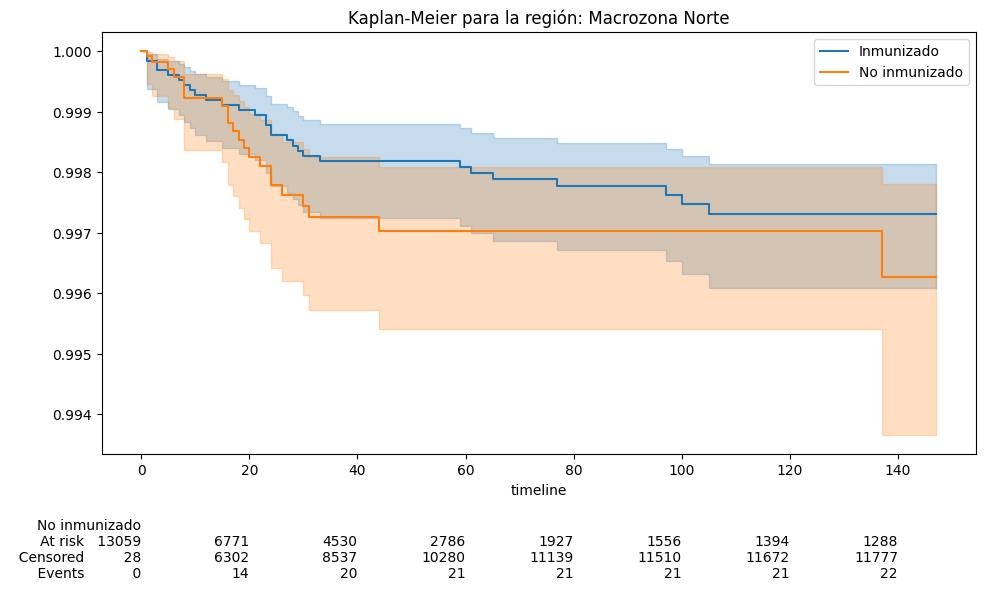

         test_statistic         p  -log2(p)
0.0 1.0        1.230124  0.267383  1.903021


macrozona: Macrozona Austral
INMUNE, NO INMUNE
MAXIMO TIEMPO: 146.0 147.0
MEDIA TIEMPO: 94.87961385576376 27.584581253466446


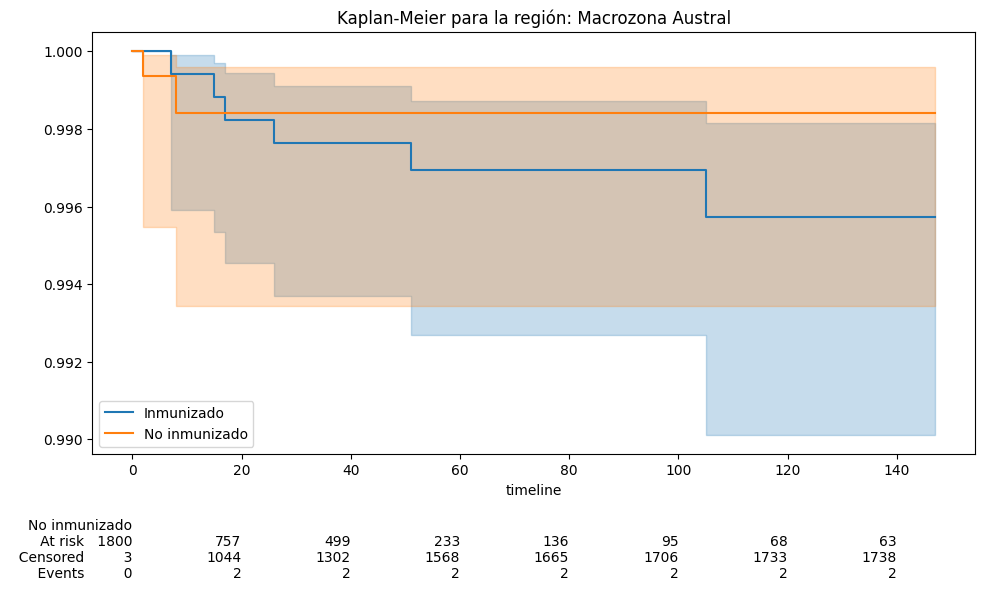

         test_statistic         p  -log2(p)
0.0 1.0        0.142049  0.706252  0.501744


macrozona: Macrozona Centro Norte
INMUNE, NO INMUNE
MAXIMO TIEMPO: 147.0 147.0
MEDIA TIEMPO: 97.74125214740567 29.575049190919504


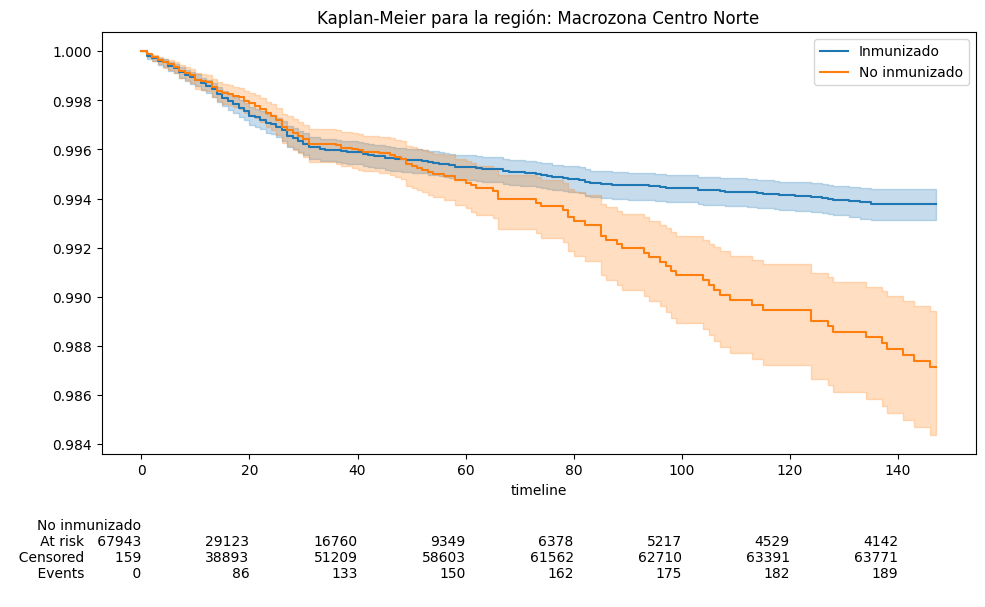

         test_statistic         p  -log2(p)
0.0 1.0        8.287869  0.003991  7.969005


macrozona: Macrozona Centro Sur
INMUNE, NO INMUNE
MAXIMO TIEMPO: 147.0 147.0
MEDIA TIEMPO: 96.4418471100902 29.048458445040215


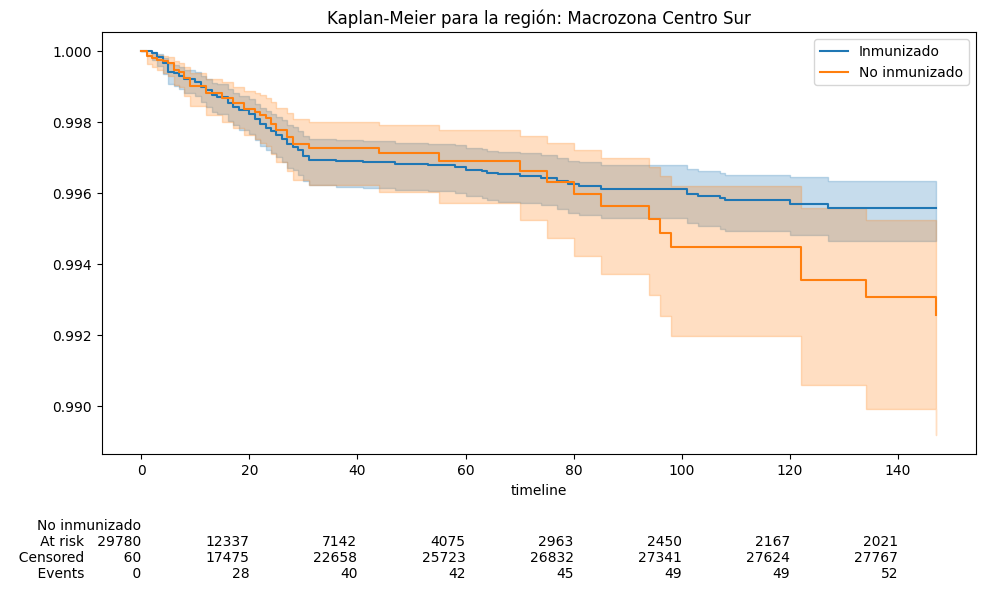

         test_statistic         p  -log2(p)
0.0 1.0        0.486667  0.485418  1.042701


macrozona: Macrozona Sur
INMUNE, NO INMUNE
MAXIMO TIEMPO: 147.0 147.0
MEDIA TIEMPO: 93.10139460448103 33.95249169435216


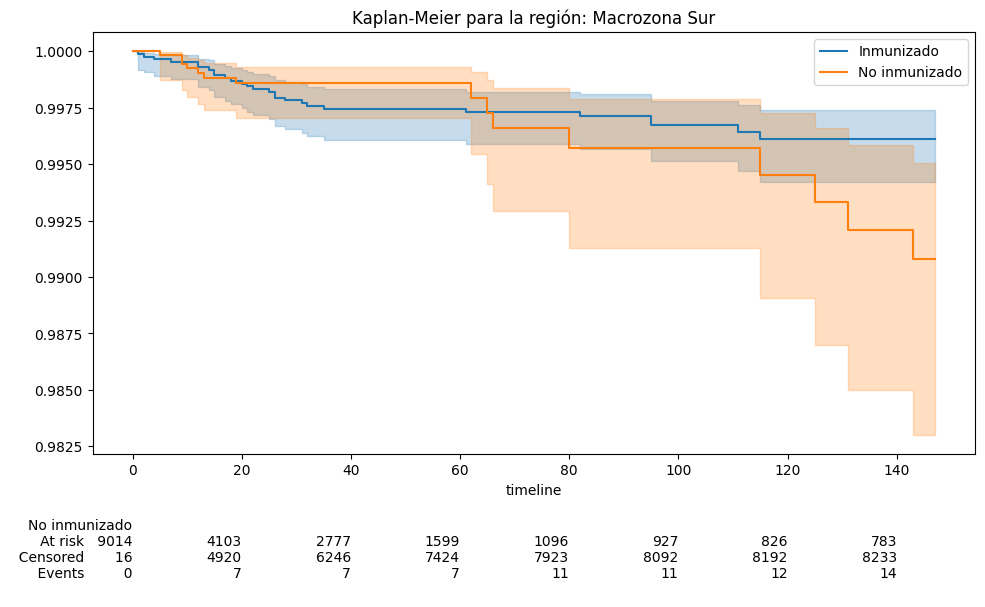

         test_statistic         p  -log2(p)
0.0 1.0        0.357086  0.550129  0.862159




,region,p_value
0,Macrozona Norte,0.267
1,Macrozona Austral,0.706
2,Macrozona Centro Norte,0.004
3,Macrozona Centro Sur,0.485
4,Macrozona Sur,0.550


In [79]:
macrozonas = df_mayer_vrs['macrozona_v1'].unique()
t = np.linspace(0, int(df_mayer_vrs.duration.max()),  int(df_mayer_vrs.duration.max())+1) 
resultados_log_rank = []
for i in macrozonas:
    if pd.isnull(i):
        continue
    else:
        print("macrozona:", i)
        d_reg = df_mayer_vrs.query('macrozona_v1==' + '"' + i + '"')
        d_reg_agg = (
            d_reg[['RUN','event_vrs', 'duration', 'inmunizado']]
            .groupby(['RUN', 'inmunizado', 'event_vrs'], as_index=False) 
            .agg({'duration': 'sum'}) 
        )
        
        T = d_reg_agg["duration"]  
        E = d_reg_agg["event_vrs"]  
        inmunizado = d_reg_agg["inmunizado"]  
        
        print("INMUNE, NO INMUNE")
        print('MAXIMO TIEMPO:', T[inmunizado == 1].max(), T[inmunizado == 0].max())
        print('MEDIA TIEMPO:', T[inmunizado == 1].mean(), T[inmunizado == 0].mean())
        
        plt.figure(figsize=(10, 6))  
        ax = plt.subplot(111)
        
        kmf = KaplanMeierFitter()
        
        #kmf.fit(T, event_observed=E, label="General")
        #kmf.plot_survival_function(ax=ax)

        kmf.fit(T[inmunizado == 1], event_observed=E[inmunizado == 1], timeline=t, label="Inmunizado")
        kmf.plot_survival_function(ax=ax)
        
        kmf.fit(T[inmunizado == 0], event_observed=E[inmunizado == 0], timeline=t, label="No inmunizado")
        kmf.plot_survival_function(ax=ax)
        
        add_at_risk_counts(kmf, ax=ax)
        
        plt.tight_layout()
        plt.title(f'Kaplan-Meier para la región: {i}')
        plt.show()
        
        log_rank = pairwise_logrank_test(T, inmunizado, E)
        print(log_rank.summary)
        print('\n')
    
        p_value = round(log_rank.p_value[0],3) 
        #test_stat = log_rank.test_statistic[0]  

        resultados_log_rank.append({
            'region': i,
            'p_value': p_value #,'test_statistic': test_stat
        })

# Convertir la lista de resultados en un DataFrame
df_log_rank = pd.DataFrame(resultados_log_rank)

# Mostrar el DataFrame final con los resultados
display(df_log_rank)

In [ ]:
macrozonas = df_vrs_post['macrozona_v1'].unique()
for i in macrozonas:
    if pd.isnull(i):
        continue
    else:
        print("macrozona:", i)
        
        d_reg = df_vrs_post.query(f'macrozona_v1 == "{i}"') 
        vrs_inmue_time = (
            d_reg  
            .copy()
            .query('group==1')
            .assign(time_inmue = lambda x: np.where(x.inmunizado==1, x.start, pd.NA))
            .assign(time_vrs = lambda x: np.where(x.event_vrs==1, x.stop, pd.NA))
            .assign(vrs_inmune = lambda x: np.where(x.event_vrs==1, "VRS", np.where(x.inmunizado==1,'inmunizado',pd.NA)))
            .drop_duplicates(subset=['RUN','vrs_inmune'], keep='first')
        )   
            
        plt.figure(figsize=(10, 6))
        
        sns.kdeplot(vrs_inmue_time['time_inmue'].dropna(), label='Inmunizado_CATCHUP', common_norm=False, bw_adjust=1, linestyle='-')
        sns.kdeplot(vrs_inmue_time['time_vrs'].dropna(), label='VRS_CATCHUP', common_norm=False, bw_adjust=1, linestyle='-')
        
        vrs_inmue_nb_time = (
            d_reg  
            .copy()
            .query('group==0')
            .assign(time_inmue = lambda x: np.where(x.inmunizado==1, x.start, pd.NA))
            .assign(time_vrs = lambda x: np.where(x.event_vrs==1, x.stop, pd.NA))
            .assign(vrs_inmune = lambda x: np.where(x.event_vrs==1, "VRS", np.where(x.inmunizado==1,'inmunizado',pd.NA)))
            .drop_duplicates(subset=['RUN','vrs_inmune'], keep='first')
        )   

        sns.kdeplot(vrs_inmue_nb_time['time_inmue'].dropna(), label='Inmunizado_NB', common_norm=False, bw_adjust=1, linestyle='--')
        sns.kdeplot(vrs_inmue_nb_time['time_vrs'].dropna(), label='VRS_NB', common_norm=False, bw_adjust=1, linestyle='--')
        
        plt.legend(title="Grupo", loc='upper left', bbox_to_anchor=(1, 1))  
        
        plt.title(f"VRS V/S inmunización para la Región: {i}")
        
        plt.tight_layout()
        
        plt.xticks(ticks=range(-50, 175, 10))
        plt.xlabel(xlabel='Time')

        plt.show()

In [ ]:
macrozonas = df_mayer_vrs['macrozona_v1'].unique()
t = np.linspace(0, int(df_mayer_vrs.duration.max()),  int(df_mayer_vrs.duration.max())+1) 
resultados_log_rank = []
for i in macrozonas:
    if pd.isnull(i):
        continue
    else:
        print("macrozona:", i)
        d_reg = df_mayer_vrs.query('macrozona_v1==' + '"' + i + '"')
        d_reg_agg = (
            d_reg[['RUN','event_vrs', 'duration', 'inmunizado']]
            .groupby(['RUN', 'inmunizado', 'event_vrs'], as_index=False) 
            .agg({'duration': 'sum'}) 
        )
        
        T = d_reg_agg["duration"]  
        E = d_reg_agg["event_vrs"]  
        inmunizado = d_reg_agg["inmunizado"]  
        
        print("INMUNE, NO INMUNE")
        print('MAXIMO TIEMPO:', T[inmunizado == 1].max(), T[inmunizado == 0].max())
        print('MEDIA TIEMPO:', T[inmunizado == 1].mean(), T[inmunizado == 0].mean())
        
        plt.figure(figsize=(10, 6))  
        ax = plt.subplot(111)
        
        kmf = KaplanMeierFitter()

        kmf.fit(T[inmunizado == 1], event_observed=E[inmunizado == 1], timeline=t, label="Inmunizado")
        kmf.plot_survival_function(ax=ax)
        
        kmf.fit(T[inmunizado == 0], event_observed=E[inmunizado == 0], timeline=t, label="No inmunizado")
        kmf.plot_survival_function(ax=ax)
        
        plt.title(f'KM y circulacion macrozona: {i}')

        
        log_rank = pairwise_logrank_test(T, inmunizado, E)
        print(log_rank.summary)
        print('\n')
    
        p_value = round(log_rank.p_value[0],3) 

        resultados_log_rank.append({
            'region': i,
            'p_value': p_value 
        })
        
        d_reg = df_vrs_post.query(f'macrozona_v1 == "{i}"') 
        vrs_inmue_time = (
            d_reg  
            .copy()
            .assign(time_inmue = lambda x: np.where(x.inmunizado==1, x.start, pd.NA))
            .assign(time_vrs = lambda x: np.where(x.event_vrs==1, x.stop, pd.NA))
            .assign(vrs_inmune = lambda x: np.where(x.event_vrs==1, "VRS", np.where(x.inmunizado==1,'inmunizado',pd.NA)))
            .drop_duplicates(subset=['RUN','vrs_inmune'], keep='first')
        )   

        sns.kdeplot(vrs_inmue_time['time_vrs'].dropna(), label='VRS', common_norm=False, bw_adjust=1, linestyle='-')
        
        plt.legend(title="Grupo", loc='upper left', bbox_to_anchor=(1, 1))  
        
        plt.tight_layout()
        
        plt.xticks(ticks=range(0, 175, 10))
        plt.xlabel(xlabel='Time')

        plt.show()

In [ ]:
df_mayer_vrs = df_mayer_vrs.assign(leo_zonas = lambda x: x.macrozona_v1.replace({'Macrozona Centro Sur':'South Macrozone',
                                                                               'Macrozona Sur':'South Macrozone',
                                                                               'Macrozona Norte':'North Macrozone',
                                                                               'Macrozona Centro Norte':'North Center Macrozone',
                                                                               'Macrozona Austral':'Austral Macrozone'}))

df_mayer_upc = df_mayer_upc.assign(leo_zonas = lambda x: x.macrozona_v1.replace({'Macrozona Centro Sur':'South Macrozone',
                                                                               'Macrozona Sur':'South Macrozone',
                                                                               'Macrozona Norte':'North Macrozone',
                                                                               'Macrozona Centro Norte':'North Center Macrozone',
                                                                               'Macrozona Austral':'Austral Macrozone'}))

df_vrs_post = df_vrs_post.assign(leo_zonas = lambda x: x.macrozona_v1.replace({'Macrozona Centro Sur':'South Macrozone',
                                                                               'Macrozona Sur':'South Macrozone',
                                                                               'Macrozona Norte':'North Macrozone',
                                                                               'Macrozona Centro Norte':'North Center Macrozone',
                                                                               'Macrozona Austral':'Austral Macrozone'}))
df_upc_post = df_upc_post.assign(leo_zonas = lambda x: x.macrozona_v1.replace({'Macrozona Centro Sur':'South Macrozone',
                                                                               'Macrozona Sur':'South Macrozone',
                                                                               'Macrozona Norte':'North Macrozone',
                                                                               'Macrozona Centro Norte':'North Center Macrozone',
                                                                               'Macrozona Austral':'Austral Macrozone'}))

In [30]:
colorss = sns.color_palette("bright")[:len(macrozonas)]
colorss

[(0.00784313725490196, 0.24313725490196078, 1.0),
 (1.0, 0.48627450980392156, 0.0),
 (0.10196078431372549, 0.788235294117647, 0.2196078431372549),
 (0.9098039215686274, 0.0, 0.043137254901960784),
 (0.5450980392156862, 0.16862745098039217, 0.8862745098039215)]

,Macrozone,p_value
0,Austral Macrozone,0.706
1,North Center Macrozone,0.004
2,North Macrozone,0.267
3,South Macrozone,0.371


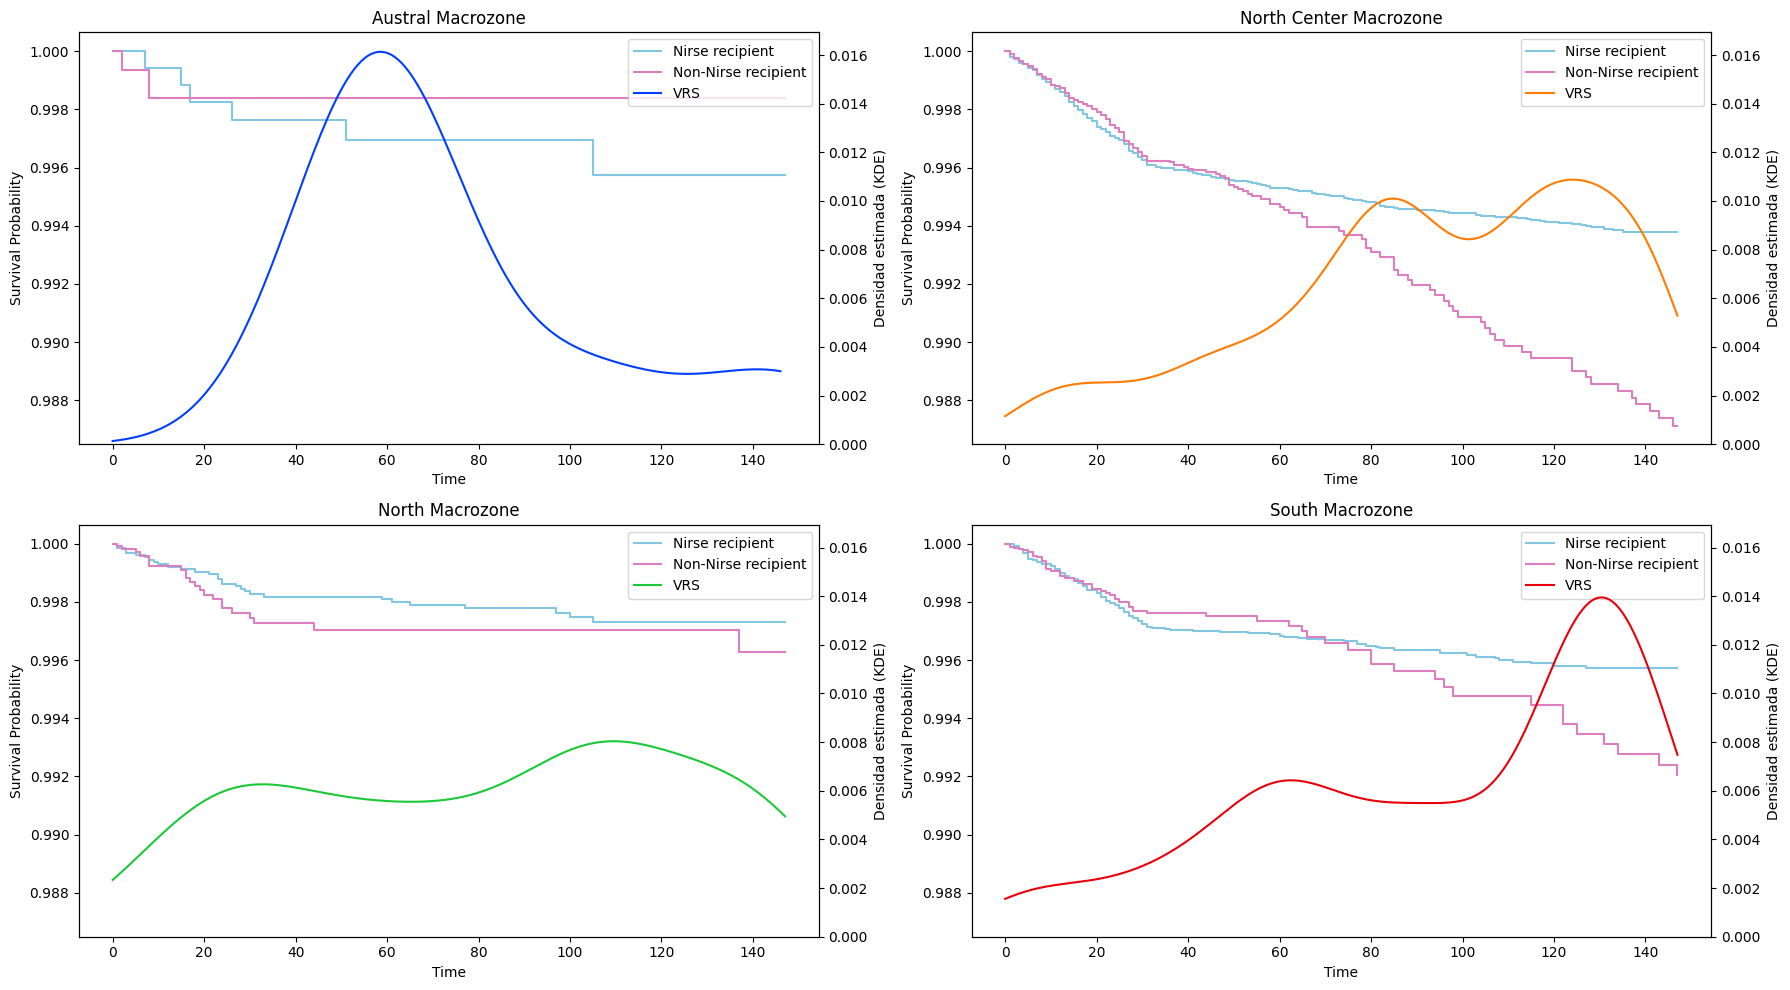

In [58]:
# Código ajustado para leyendas unificadas por subplot
macrozonas = df_mayer_vrs.sort_values(by='leo_zonas')['leo_zonas'].unique()
t = np.linspace(0, int(df_mayer_vrs.duration.max()), int(df_mayer_vrs.duration.max()) + 1)
num_macrozones = len([i for i in macrozonas if not pd.isnull(i)]) + 1
cols = 2  # Número de columnas en los subplots
rows = 2  # Dos filas para los gráficos

fig, axes = plt.subplots(rows, cols, figsize=(18, 10), squeeze=False)
colorss = sns.color_palette("bright")[:len(macrozonas)]

plt.subplots_adjust(hspace=0.4, wspace=0.5)

y_limits_kmf = [float('inf'), -float('inf')]
y_limits_kde = [float('inf'), -float('inf')]
resultados_log_rank = []
right_axes = {}

for idx, (i, ax) in enumerate(zip(macrozonas, axes.flatten())):
    if pd.isnull(i):
        continue

    d_reg = df_mayer_vrs.sort_values(by='leo_zonas').query(f'leo_zonas=="{i}"')
    d_reg_agg = (
        d_reg[['RUN', 'event_vrs', 'duration', 'inmunizado']]
        .groupby(['RUN', 'inmunizado', 'event_vrs'], as_index=False)
        .agg({'duration': 'sum'})
    )

    T = d_reg_agg["duration"]
    E = d_reg_agg["event_vrs"]
    inmunizado = d_reg_agg["inmunizado"]

    # Gráfico Kaplan-Meier en el eje principal
    kmf = KaplanMeierFitter()

    # Nirse recipient
    kmf.fit(T[inmunizado == 1], event_observed=E[inmunizado == 1], timeline=t, label="Nirse recipient")
    km_line_nirse = kmf.plot_survival_function(ax=ax, color=sns.color_palette("muted")[9], ci_show=False)

    # Non-Nirse recipient
    kmf.fit(T[inmunizado == 0], event_observed=E[inmunizado == 0], timeline=t, label="Non-Nirse recipient")
    km_line_non_nirse = kmf.plot_survival_function(ax=ax, color=sns.color_palette("muted")[6], ci_show=False)

    log_rank = pairwise_logrank_test(T, inmunizado, E)
    p_value = round(log_rank.p_value[0], 3)
    resultados_log_rank.append({'Macrozone': i, 'p_value': p_value})

    # Actualizar límites Y de Kaplan-Meier
    y_limits_kmf[0] = min(y_limits_kmf[0], ax.get_ylim()[0])
    y_limits_kmf[1] = max(y_limits_kmf[1], ax.get_ylim()[1])

    ax.set_title(f'{i}')
    ax.set_ylabel("Survival Probability")
    ax.set_xlabel("Time")

    # Crear el segundo eje para el KDE
    ax_kde = ax.twinx()
    right_axes[idx] = ax_kde

    d_reg = df_vrs_post.sort_values(by='leo_zonas').query(f'leo_zonas == "{i}"')
    vrs_inmue_time = (
        d_reg
        .copy()
        .assign(time_inmue=lambda x: np.where(x.inmunizado == 1, x.start, pd.NA))
        .assign(time_vrs=lambda x: np.where(x.event_vrs == 1, x.stop, pd.NA))
        .assign(vrs_inmune=lambda x: np.where(x.event_vrs == 1, "VRS", np.where(x.inmunizado == 1, 'inmunizado', pd.NA)))
        .drop_duplicates(subset=['RUN', 'vrs_inmune'], keep='first')
    )

    kde_line = sns.kdeplot(
        vrs_inmue_time['time_vrs'].dropna(),
        ax=ax_kde,
        label='VRS',
        color=colorss[idx],
        common_norm=False,
        bw_adjust=0.8,
        linestyle='-',
        clip=(0, T[inmunizado == 1].max())
    )

    ax_kde.set_ylabel("Densidad estimada (KDE)")
    y_limits_kde[0] = min(y_limits_kde[0], ax_kde.get_ylim()[0])
    y_limits_kde[1] = max(y_limits_kde[1], ax_kde.get_ylim()[1])

    # Unificar las leyendas en el subplot principal
    handles_km, labels_km = ax.get_legend_handles_labels()
    handles_kde, labels_kde = ax_kde.get_legend_handles_labels()
    ax.legend(handles=handles_km + handles_kde, labels=labels_km + labels_kde, loc='upper right')

# Ajustar límites de todos los subplots
for idx, (i, ax) in enumerate(zip(macrozonas, axes.flatten())):
    if not pd.isnull(i):
        ax.set_ylim(y_limits_kmf)  # Límite de Kaplan-Meier
        right_axes[idx].set_ylim(y_limits_kde)

df_log_rank = pd.DataFrame(resultados_log_rank)
display(df_log_rank)

plt.tight_layout()
plt.show()


,Macrozone,p_value
0,Macrozona Austral,0.706
1,Macrozona Centro Norte,0.004
2,Macrozona Norte,0.267
3,Macrozona Sur,0.371


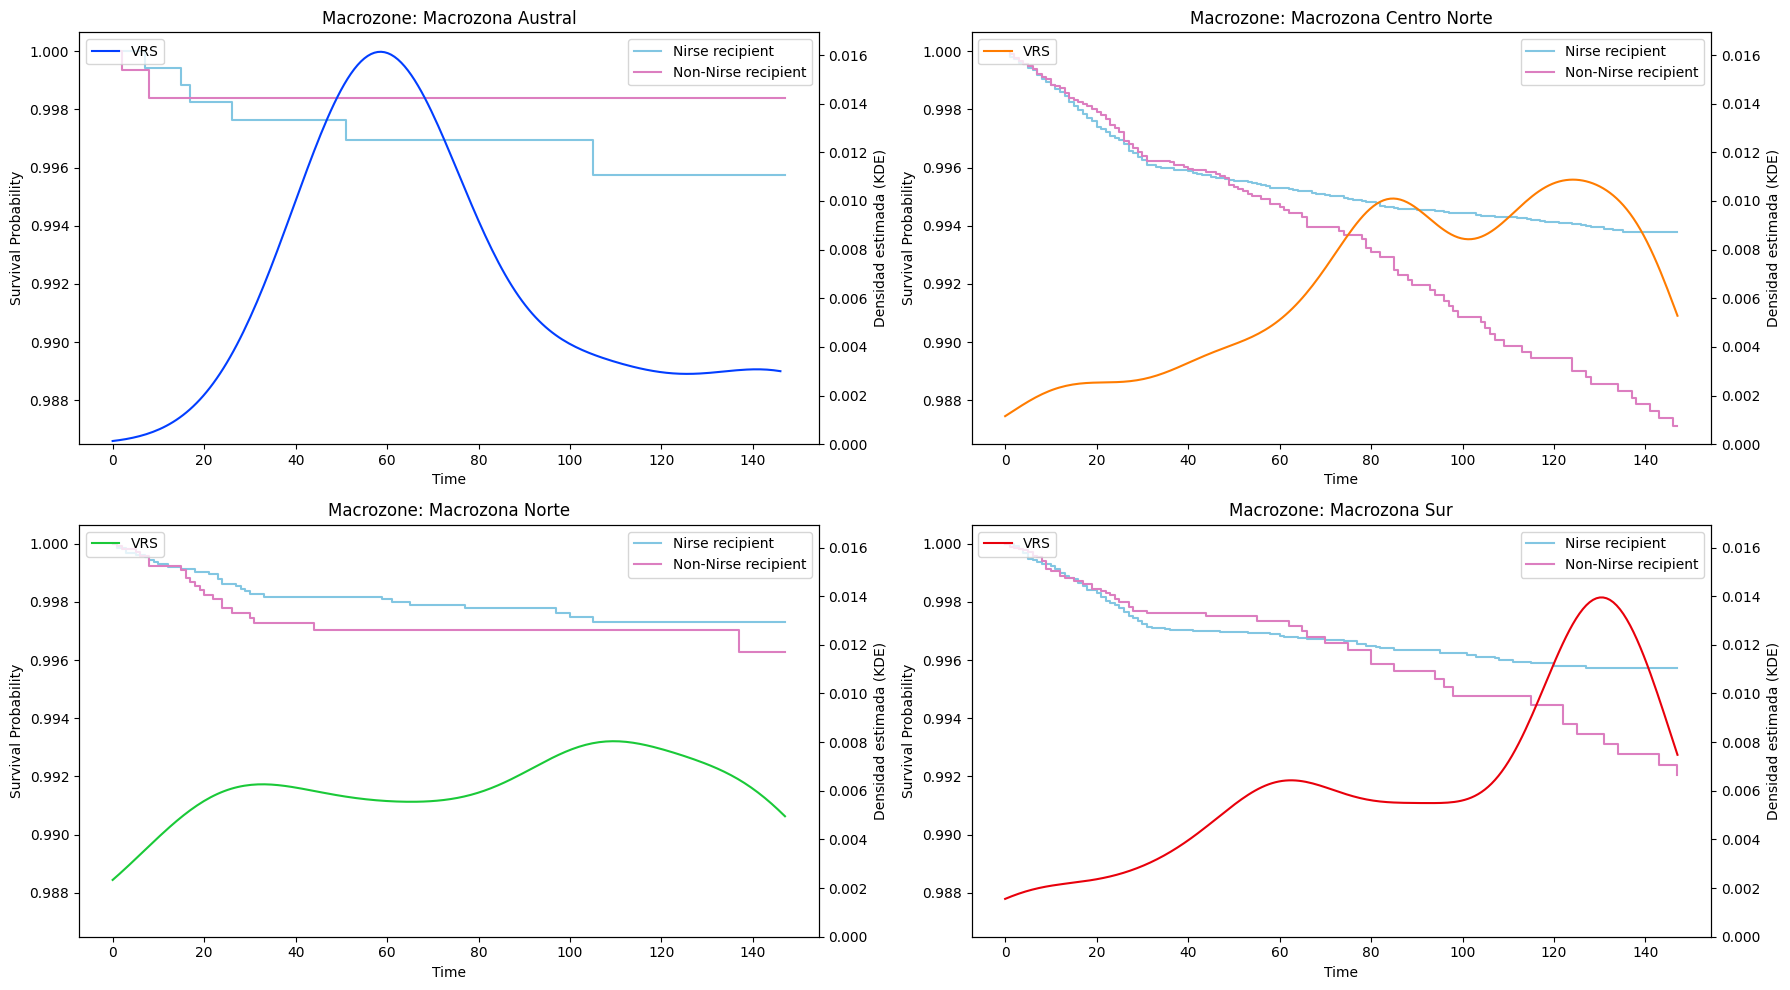

In [ ]:
macrozonas = df_mayer_vrs.sort_values(by='leo_zonas')['leo_zonas'].unique()
t = np.linspace(0, int(df_mayer_vrs.duration.max()),  int(df_mayer_vrs.duration.max())+1) 
num_macrozones = len([i for i in macrozonas if not pd.isnull(i)]) + 1
cols = 2  # Número de columnas en los subplots
rows = 2  # Dos filas para los gráficos

fig, axes = plt.subplots(rows, cols, figsize=(18, 10), squeeze=False)
colorss = sns.color_palette("bright")[:len(macrozonas)]

plt.subplots_adjust(hspace=0.4, wspace=0.5)

# Lista para almacenar líneas KDE para el sexto subplot
combined_ax = axes[-1, -1]
y_limits_kmf = [float('inf'), -float('inf')]  # Para ajustar límites de KM
y_limits_kde = [float('inf'), -float('inf')]  # Para ajustar límites de KDE
resultados_log_rank = []
right_axes = {}
for idx, (i, ax) in enumerate(zip(macrozonas, axes.flatten())):
    if pd.isnull(i):
        continue

    d_reg = df_mayer_vrs.sort_values(by='leo_zonas').query(f'leo_zonas=="{i}"')
    d_reg_agg = (
        d_reg[['RUN', 'event_vrs', 'duration', 'inmunizado']]
        .groupby(['RUN', 'inmunizado', 'event_vrs'], as_index=False)
        .agg({'duration': 'sum'})
    )

    T = d_reg_agg["duration"]
    E = d_reg_agg["event_vrs"]
    inmunizado = d_reg_agg["inmunizado"]

    # Gráfico Kaplan-Meier en el eje principal
    kmf = KaplanMeierFitter()

    kmf.fit(T[inmunizado == 1], event_observed=E[inmunizado == 1], timeline=t, label="Nirse recipient")
    kmf.plot_survival_function(ax=ax, color=sns.color_palette("muted")[9], ci_show=False)

    kmf.fit(T[inmunizado == 0], event_observed=E[inmunizado == 0], timeline=t, label="Non-Nirse recipient")
    kmf.plot_survival_function(ax=ax, color=sns.color_palette("muted")[6], ci_show=False)

    
    log_rank = pairwise_logrank_test(T, inmunizado, E)

    p_value = round(log_rank.p_value[0],3) 

    resultados_log_rank.append({
        'Macrozone': i,
        'p_value': p_value #,'test_statistic': test_stat
    })
    
    # Actualizar límites Y de Kaplan-Meier
    y_limits_kmf[0] = min(y_limits_kmf[0], ax.get_ylim()[0])
    y_limits_kmf[1] = max(y_limits_kmf[1], ax.get_ylim()[1])
    # y_limits_kmf[0] = ax.get_ylim()[0]
    # y_limits_kmf[1] = ax.get_ylim()[1]

    ax.set_title(f'Macrozone: {i}')
    ax.set_ylabel("Survival Probability")
    ax.set_xlabel("Time")
    ax.legend(loc='upper right')

    # Crear el segundo eje para el KDE
    ax_kde = ax.twinx()
    right_axes[idx] = ax_kde 
     
    d_reg = df_vrs_post.sort_values(by='leo_zonas').query(f'leo_zonas == "{i}"')
    vrs_inmue_time = (
        d_reg
        .copy()
        .assign(time_inmue=lambda x: np.where(x.inmunizado == 1, x.start, pd.NA))
        .assign(time_vrs=lambda x: np.where(x.event_vrs == 1, x.stop, pd.NA))
        .assign(vrs_inmune=lambda x: np.where(x.event_vrs == 1, "VRS", np.where(x.inmunizado == 1, 'inmunizado', pd.NA)))
        .drop_duplicates(subset=['RUN', 'vrs_inmune'], keep='first')
    )

    kde_line = sns.kdeplot(
        vrs_inmue_time['time_vrs'].dropna(),
        ax=ax_kde,
        label='VRS',
        color=colorss[idx],
        common_norm=False,
        bw_adjust=0.8,
        linestyle='-',
        clip=(0, T[inmunizado == 1].max())
    )

    ax_kde.set_ylabel("Densidad estimada (KDE)")
    ax_kde.legend(loc='upper left')
    
    y_limits_kde[0] = min(y_limits_kde[0], ax_kde.get_ylim()[0])
    y_limits_kde[1] = max(y_limits_kde[1], ax_kde.get_ylim()[1])
# Establecer los mismos límites Y en todos los subplots
for idx, (i, ax) in enumerate(zip(macrozonas, axes.flatten())):
    if not pd.isnull(i):
        ax.set_ylim(y_limits_kmf)  # Límite de Kaplan-Meier
        right_axes[idx].set_ylim(y_limits_kde)
            

# data_plt = (
#     df_vrs_post
#     .copy()
#     .sort_values(by='leo_zonas')
#     .assign(time_inmue=lambda x: np.where(x.inmunizado == 1, x.start, pd.NA),
#             time_vrs=lambda x: np.where(x.event_vrs == 1, x.stop, pd.NA),
#             vrs_inmune=lambda x: np.where(x.event_vrs == 1, "VRS", np.where(x.inmunizado == 1, 'inmunizado', pd.NA)))
#     .drop_duplicates(subset=['RUN', 'vrs_inmune'], keep='first')
#     .dropna(subset=['time_vrs'])
# )

# sns.kdeplot(data_plt,
#             x='time_vrs',
#             hue='leo_zonas',
#             ax=combined_ax,
#             common_norm=False,
#             bw_adjust=0.8,
#             palette="bright",
#             linestyle='-',
#             clip=(0, 147)
# )

# combined_ax.set_title("Benchmark Circulation on Campaign")
# combined_ax.set_xlabel("Time")
# combined_ax.set_ylabel("Estimated Density")
# combined_ax.legend(title="Macrozone", loc='upper left', labels = data_plt['leo_zonas'].unique()[::-1])

# Convertir la lista de resultados en un DataFrame
df_log_rank = pd.DataFrame(resultados_log_rank)
display(df_log_rank)

plt.tight_layout()
plt.show()

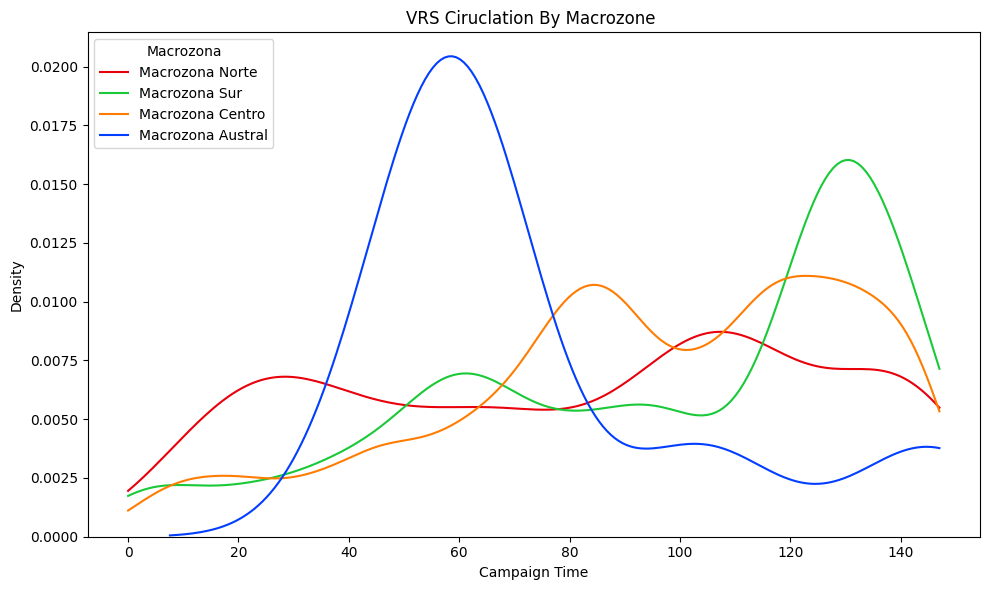

In [ ]:
data_plt = (
    df_vrs_post
    .copy()
    .sort_values(by='macrozona_v1')
    .assign(time_inmue=lambda x: np.where(x.inmunizado == 1, x.start, pd.NA),
            time_vrs=lambda x: np.where(x.event_vrs == 1, x.stop, pd.NA),
            vrs_inmune=lambda x: np.where(x.event_vrs == 1, "VRS", np.where(x.inmunizado == 1, 'inmunizado', pd.NA)),
            leo_zonas = lambda x: x.macrozona_v1.replace({'Macrozona Centro Sur':'Macrozona Sur','Macrozona Centro Norte':'Macrozona Centro'}))
    .drop_duplicates(subset=['RUN', 'vrs_inmune'], keep='first')
    .dropna(subset=['time_vrs'])
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.kdeplot(data_plt,
            x='time_vrs',
            hue='leo_zonas',
            common_norm=False,
            bw_adjust=0.6,
            palette="bright",
            linestyle='-',
            clip=(0, 147),
            ax=ax
)

ax.set_title("VRS Ciruclation By Macrozone ")
ax.set_xlabel("Campaign Time")
ax.set_ylabel("Density")
ax.legend(title="", loc='upper left', labels = data_plt['leo_zonas'].unique()[::-1])

plt.tight_layout()
plt.show()

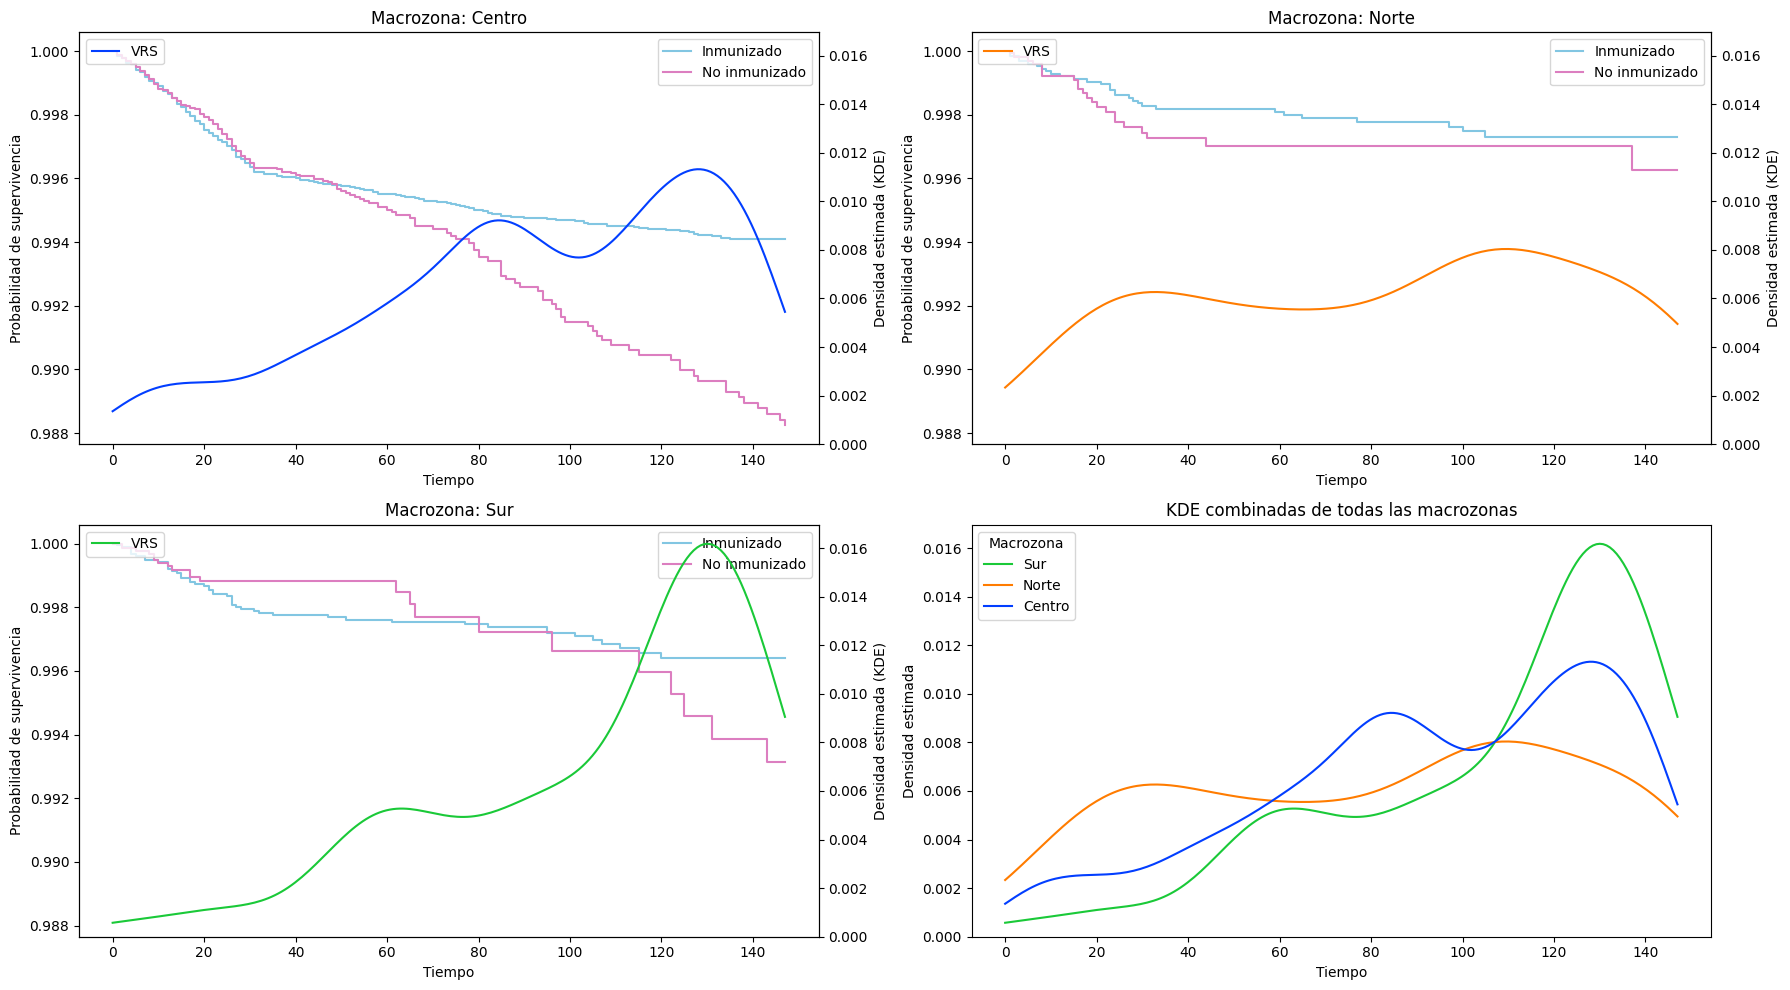

In [17]:
macrozonas = df_mayer_vrs.sort_values(by='Macrozona2')['Macrozona2'].unique()
num_macrozones = len([i for i in macrozonas if not pd.isnull(i)]) + 1
cols = 2  # Número de columnas en los subplots
rows = 2  # Dos filas para los gráficos

fig, axes = plt.subplots(rows, cols, figsize=(18, 10), squeeze=False)
colorss = sns.color_palette("bright")[:len(macrozonas)]

# Lista para almacenar líneas KDE para el sexto subplot
combined_ax = axes[-1, -1]
y_limits_kmf = [float('inf'), -float('inf')]  # Para ajustar límites de KM
y_limits_kde = [float('inf'), -float('inf')]  # Para ajustar límites de KDE

right_axes = {}
for idx, (i, ax) in enumerate(zip(macrozonas, axes.flatten()[:-1])):
    if pd.isnull(i):
        continue

    d_reg = df_mayer_vrs.sort_values(by='Macrozona2').query('Macrozona2==' + '"' + i + '"')
    d_reg_agg = (
        d_reg[['RUN', 'event_vrs', 'duration', 'inmunizado']]
        .groupby(['RUN', 'inmunizado', 'event_vrs'], as_index=False)
        .agg({'duration': 'sum'})
    )

    T = d_reg_agg["duration"]
    E = d_reg_agg["event_vrs"]
    inmunizado = d_reg_agg["inmunizado"]

    # Gráfico Kaplan-Meier en el eje principal
    kmf = KaplanMeierFitter()

    kmf.fit(T[inmunizado == 1], event_observed=E[inmunizado == 1], timeline=t, label="Inmunizado")
    kmf.plot_survival_function(ax=ax, color=sns.color_palette("muted")[9], ci_show=False)

    kmf.fit(T[inmunizado == 0], event_observed=E[inmunizado == 0], timeline=t, label="No inmunizado")
    kmf.plot_survival_function(ax=ax, color=sns.color_palette("muted")[6], ci_show=False)

    # Actualizar límites Y de Kaplan-Meier
    y_limits_kmf[0] = min(y_limits_kmf[0], ax.get_ylim()[0])
    y_limits_kmf[1] = max(y_limits_kmf[1], ax.get_ylim()[1])
    # y_limits_kmf[0] = ax.get_ylim()[0]
    # y_limits_kmf[1] = ax.get_ylim()[1]

    ax.set_title(f'Macrozona: {i}')
    ax.set_ylabel("Probabilidad de supervivencia")
    ax.set_xlabel("Tiempo")
    ax.legend(loc='upper right')

    # Crear el segundo eje para el KDE
    ax_kde = ax.twinx()
    right_axes[idx] = ax_kde 
     
    d_reg = df_vrs_post.sort_values(by='Macrozona2').query(f'Macrozona2 == "{i}"')
    vrs_inmue_time = (
        d_reg
        .copy()
        .assign(time_inmue=lambda x: np.where(x.inmunizado == 1, x.start, pd.NA))
        .assign(time_vrs=lambda x: np.where(x.event_vrs == 1, x.stop, pd.NA))
        .assign(vrs_inmune=lambda x: np.where(x.event_vrs == 1, "VRS", np.where(x.inmunizado == 1, 'inmunizado', pd.NA)))
        .drop_duplicates(subset=['RUN', 'vrs_inmune'], keep='first')
    )

    kde_line = sns.kdeplot(
        vrs_inmue_time['time_vrs'].dropna(),
        ax=ax_kde,
        label='VRS',
        color=colorss[idx],
        common_norm=False,
        bw_adjust=0.8,
        linestyle='-',
        clip=(0, T[inmunizado == 1].max())
    )

    ax_kde.set_ylabel("Densidad estimada (KDE)")
    ax_kde.legend(loc='upper left')
    y_limits_kde[0] = min(y_limits_kde[0], ax_kde.get_ylim()[0])
    y_limits_kde[1] = max(y_limits_kde[1], ax_kde.get_ylim()[1])
# Establecer los mismos límites Y en todos los subplots
for idx, (i, ax) in enumerate(zip(macrozonas, axes.flatten()[:-1])):
    if not pd.isnull(i):
        ax.set_ylim(y_limits_kmf)  # Límite de Kaplan-Meier
        right_axes[idx].set_ylim(y_limits_kde)
            
dict_temperatura = {
    
}

data_plt = (
    df_vrs_post
    .copy()
    .sort_values(by='Macrozona2')
    .assign(time_inmue=lambda x: np.where(x.inmunizado == 1, x.start, pd.NA),
            time_vrs=lambda x: np.where(x.event_vrs == 1, x.stop, pd.NA),
            vrs_inmune=lambda x: np.where(x.event_vrs == 1, "VRS", np.where(x.inmunizado == 1, 'inmunizado', pd.NA))
            )
    .drop_duplicates(subset=['RUN', 'vrs_inmune'], keep='first')
    .dropna(subset=['time_vrs'])
)

sns.kdeplot(data_plt,
            x='time_vrs',
            hue='Macrozona2',
            ax=combined_ax,
            common_norm=False,
            bw_adjust=0.8,
            palette="bright",
            linestyle='-',
            clip=(0, 147)
)

combined_ax.set_title("KDE combinadas de todas las macrozonas")
combined_ax.set_xlabel("Tiempo")
combined_ax.set_ylabel("Densidad estimada")
combined_ax.legend(title="Macrozona", loc='upper left', labels = data_plt['Macrozona2'].unique()[::-1])

plt.tight_layout()
plt.show()

macrozona: Norte
macrozona: Sur
macrozona: Centro


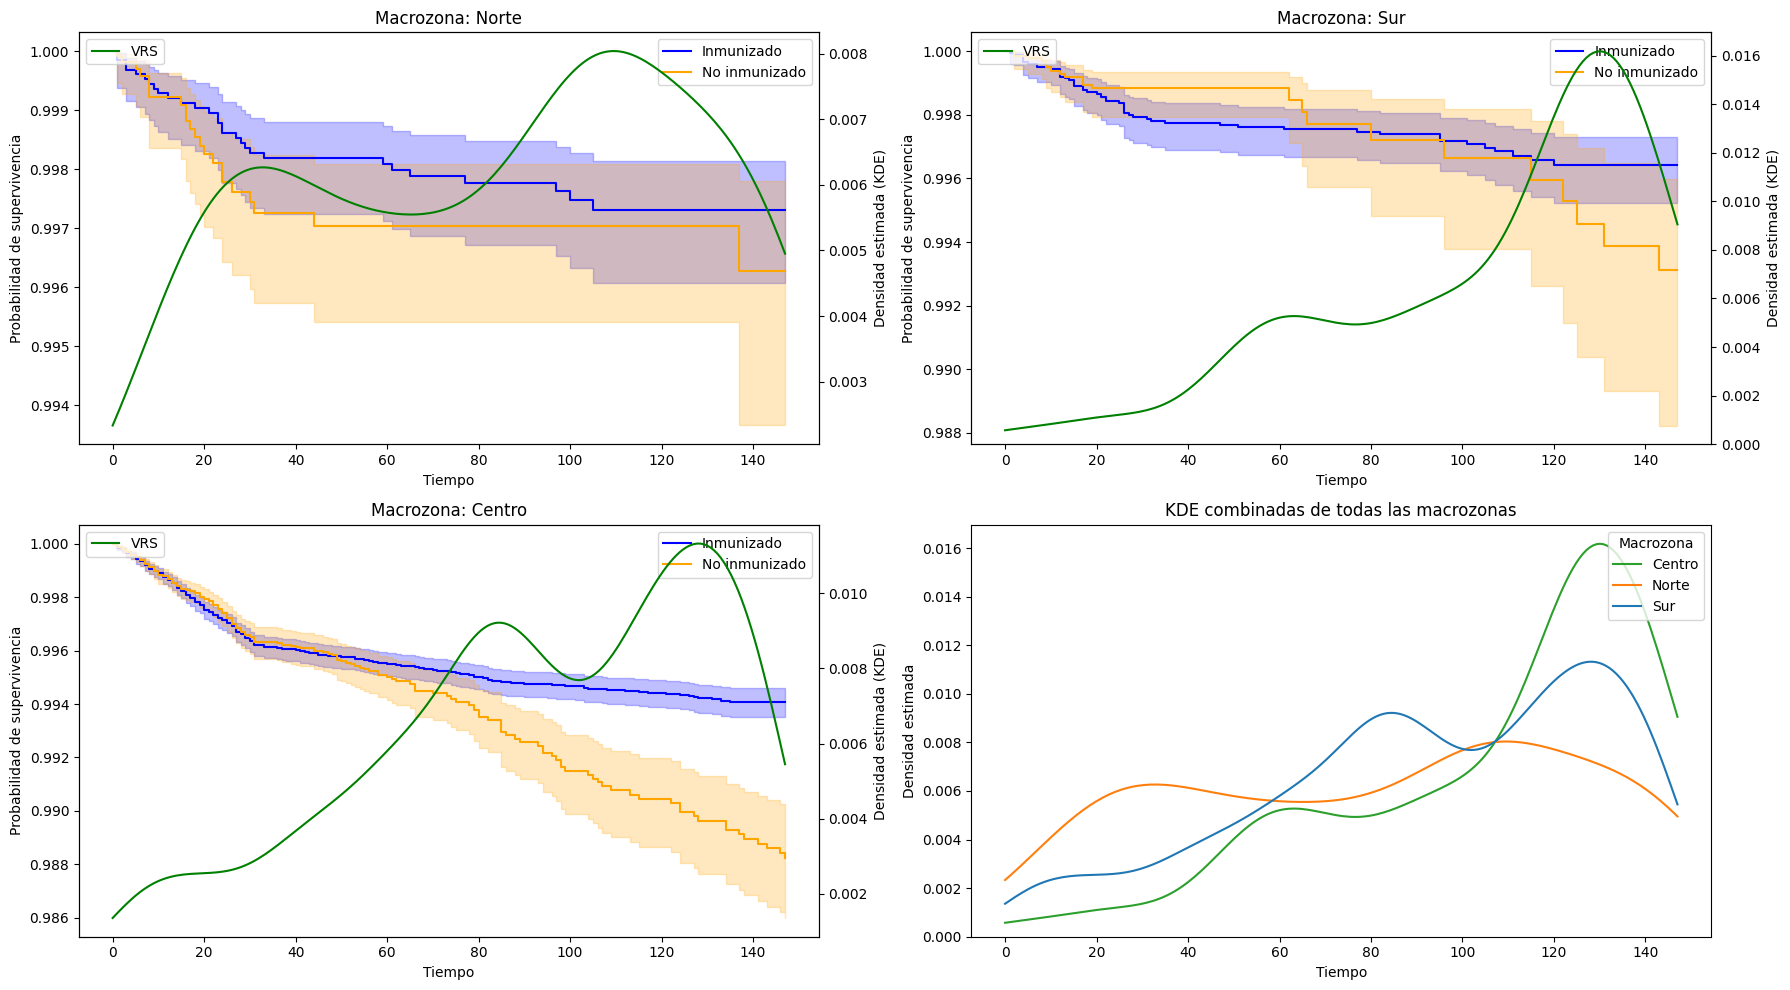

In [119]:
macrozonas = df_mayer_vrs['Macrozona2'].unique()
num_macrozones = len([i for i in macrozonas if not pd.isnull(i)]) + 1
cols = 2  # Número de columnas en los subplots
rows = 2  # Dos filas para los gráficos

fig, axes = plt.subplots(rows, cols, figsize=(18, 10), squeeze=False)

# Lista para almacenar líneas KDE para el sexto subplot
combined_ax = axes[-1, -1]
y_limits_kmf = [float('inf'), -float('inf')]  # Para ajustar límites de KM
y_limits_kde = [float('inf'), -float('inf')]  # Para ajustar límites de KDE

# Iterar sobre las macrozonas y los subplots
for idx, (i, ax) in enumerate(zip(macrozonas, axes.flatten()[:-1])):
    if pd.isnull(i):
        continue

    print("macrozona:", i)
    d_reg = df_mayer_vrs.query('Macrozona2==' + '"' + i + '"')
    d_reg_agg = (
        d_reg[['RUN', 'event_vrs', 'duration', 'inmunizado']]
        .groupby(['RUN', 'inmunizado', 'event_vrs'], as_index=False)
        .agg({'duration': 'sum'})
    )

    T = d_reg_agg["duration"]
    E = d_reg_agg["event_vrs"]
    inmunizado = d_reg_agg["inmunizado"]

    # Gráfico Kaplan-Meier en el eje principal
    kmf = KaplanMeierFitter()

    kmf.fit(T[inmunizado == 1], event_observed=E[inmunizado == 1], timeline=t, label="Inmunizado")
    kmf.plot_survival_function(ax=ax, color='blue')

    kmf.fit(T[inmunizado == 0], event_observed=E[inmunizado == 0], timeline=t, label="No inmunizado")
    kmf.plot_survival_function(ax=ax, color='orange')

    # Actualizar límites Y de Kaplan-Meier
    # y_limits_kmf[0] = min(y_limits_kmf[0], ax.get_ylim()[0])
    # y_limits_kmf[1] = max(y_limits_kmf[1], ax.get_ylim()[1])
    y_limits_kmf[0] =  ax.get_ylim()[0]
    y_limits_kmf[1] = ax.get_ylim()[1]

    ax.set_title(f'Macrozona: {i}')
    ax.set_ylabel("Probabilidad de supervivencia")
    ax.set_xlabel("Tiempo")
    ax.legend(loc='upper right')
    ax.set_ylim(y_limits_kmf) 
    
    # Crear el segundo eje para el KDE
    ax_kde = ax.twinx()

    d_reg = df_vrs_post.query(f'Macrozona2 == "{i}"')
    vrs_inmue_time = (
        d_reg
        .copy()
        .assign(time_inmue=lambda x: np.where(x.inmunizado == 1, x.start, pd.NA))
        .assign(time_vrs=lambda x: np.where(x.event_vrs == 1, x.stop, pd.NA))
        .assign(vrs_inmune=lambda x: np.where(x.event_vrs == 1, "VRS", np.where(x.inmunizado == 1, 'inmunizado', pd.NA)))
        .drop_duplicates(subset=['RUN', 'vrs_inmune'], keep='first')
    )

    kde_line = sns.kdeplot(
        vrs_inmue_time['time_vrs'].dropna(),
        ax=ax_kde,
        label='VRS',
        color='green',
        common_norm=False,
        bw_adjust=0.8,
        linestyle='-',
        clip=(0, T[inmunizado == 1].max())
    )

    ax_kde.set_ylabel("Densidad estimada (KDE)")
    ax_kde.legend(loc='upper left')
    

# # Establecer los mismos límites Y en todos los subplots
# for idx, (i, ax) in enumerate(zip(macrozonas, axes.flatten()[:-1])):
#     if not pd.isnull(i):
#         ax.set_ylim(y_limits_kmf)  # Límite de Kaplan-Meier

data_plt = (
    df_vrs_post
    .copy()
    .assign(time_inmue=lambda x: np.where(x.inmunizado == 1, x.start, pd.NA))
    .assign(time_vrs=lambda x: np.where(x.event_vrs == 1, x.stop, pd.NA))
    .assign(vrs_inmune=lambda x: np.where(x.event_vrs == 1, "VRS", np.where(x.inmunizado == 1, 'inmunizado', pd.NA)))
    .drop_duplicates(subset=['RUN', 'vrs_inmune'], keep='first')
)

sns.kdeplot(data_plt,
               x='time_vrs',
               hue='Macrozona2',
               ax=combined_ax,
               common_norm=False,
               bw_adjust=0.8,
               linestyle='-',
               clip=(0, 147)
)

combined_ax.set_title("KDE combinadas de todas las macrozonas")
combined_ax.set_xlabel("Tiempo")
combined_ax.set_ylabel("Densidad estimada")
combined_ax.legend(title="Macrozona", loc='upper right', labels=data_plt['Macrozona2'].unique())
# handles, labels = combined_ax.get_legend_handles_labels()
# combined_ax.legend(handles=handles, labels=labels, title="Macrozona", loc='upper right')

# Ajustar layout y eliminar subplots vacíos si sobran
for ax in axes.flatten()[num_macrozones:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

In [9]:
macrozonas = df_mayer_vrs['Macrozona2']==''.unique()


num_macrozones = len([i for i in macrozonas if not pd.isnull(i)]) + 1
cols = 2  # Número de columnas en los subplots
rows = 2  # Dos filas para los gráficos

fig, axes = plt.subplots(rows, cols, figsize=(18, 10), squeeze=False)

# Lista para almacenar líneas KDE para el sexto subplot
combined_ax = axes[-1, -1]
y_limits_kmf = [float('inf'), -float('inf')]  # Para ajustar límites de KM
y_limits_kde = [float('inf'), -float('inf')]  # Para ajustar límites de KDE

# Iterar sobre las macrozonas y los subplots
for idx, (i, ax) in enumerate(zip(macrozonas, axes.flatten()[:-1])):
    if pd.isnull(i):
        continue

    print("macrozona:", i)
    d_reg = df_mayer_vrs.query('Macrozona2==' + '"' + i + '"')
    d_reg_agg = (
        d_reg[['RUN', 'event_vrs', 'duration', 'inmunizado']]
        .groupby(['RUN', 'inmunizado', 'event_vrs'], as_index=False)
        .agg({'duration': 'sum'})
    )

    T = d_reg_agg["duration"]
    E = d_reg_agg["event_vrs"]
    inmunizado = d_reg_agg["inmunizado"]

    # Gráfico Kaplan-Meier en el eje principal
    kmf = KaplanMeierFitter()

    kmf.fit(T[inmunizado == 1], event_observed=E[inmunizado == 1], timeline=t, label="Inmunizado")
    kmf.plot_survival_function(ax=ax, color='blue')

    kmf.fit(T[inmunizado == 0], event_observed=E[inmunizado == 0], timeline=t, label="No inmunizado")
    kmf.plot_survival_function(ax=ax, color='orange')

    # Actualizar límites Y de Kaplan-Meier
    # y_limits_kmf[0] = min(y_limits_kmf[0], ax.get_ylim()[0])
    # y_limits_kmf[1] = max(y_limits_kmf[1], ax.get_ylim()[1])
    y_limits_kmf[0] =  ax.get_ylim()[0]
    y_limits_kmf[1] = ax.get_ylim()[1]

    ax.set_title(f'Macrozona: {i}')
    ax.set_ylabel("Probabilidad de supervivencia")
    ax.set_xlabel("Tiempo")
    ax.legend(loc='upper right')
    ax.set_ylim(y_limits_kmf) 
    
    # Crear el segundo eje para el KDE
    ax_kde = ax.twinx()

    d_reg = df_vrs_post.query(f'Macrozona2 == "{i}"')
    vrs_inmue_time = (
        d_reg
        .copy()
        .assign(time_inmue=lambda x: np.where(x.inmunizado == 1, x.start, pd.NA))
        .assign(time_vrs=lambda x: np.where(x.event_vrs == 1, x.stop, pd.NA))
        .assign(vrs_inmune=lambda x: np.where(x.event_vrs == 1, "VRS", np.where(x.inmunizado == 1, 'inmunizado', pd.NA)))
        .drop_duplicates(subset=['RUN', 'vrs_inmune'], keep='first')
    )

    kde_line = sns.kdeplot(
        vrs_inmue_time['time_vrs'].dropna(),
        ax=ax_kde,
        label='VRS',
        color='green',
        common_norm=False,
        bw_adjust=0.8,
        linestyle='-',
        clip=(0, T[inmunizado == 1].max())
    )

    ax_kde.set_ylabel("Densidad estimada (KDE)")
    ax_kde.legend(loc='upper left')
    

# # Establecer los mismos límites Y en todos los subplots
# for idx, (i, ax) in enumerate(zip(macrozonas, axes.flatten()[:-1])):
#     if not pd.isnull(i):
#         ax.set_ylim(y_limits_kmf)  # Límite de Kaplan-Meier

data_plt = (
    df_vrs_post
    .copy()
    .assign(time_inmue=lambda x: np.where(x.inmunizado == 1, x.start, pd.NA))
    .assign(time_vrs=lambda x: np.where(x.event_vrs == 1, x.stop, pd.NA))
    .assign(vrs_inmune=lambda x: np.where(x.event_vrs == 1, "VRS", np.where(x.inmunizado == 1, 'inmunizado', pd.NA)))
    .drop_duplicates(subset=['RUN', 'vrs_inmune'], keep='first')
)

sns.kdeplot(data_plt,
               x='time_vrs',
               hue='Macrozona2',
               ax=combined_ax,
               common_norm=False,
               bw_adjust=0.8,
               linestyle='-',
               clip=(0, 147)
)

combined_ax.set_title("KDE combinadas de todas las macrozonas")
combined_ax.set_xlabel("Tiempo")
combined_ax.set_ylabel("Densidad estimada")
combined_ax.legend(title="Macrozona", loc='upper right', labels=data_plt['Macrozona2'].unique())
# handles, labels = combined_ax.get_legend_handles_labels()
# combined_ax.legend(handles=handles, labels=labels, title="Macrozona", loc='upper right')

# Ajustar layout y eliminar subplots vacíos si sobran
for ax in axes.flatten()[num_macrozones:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

AttributeError: 'str' object has no attribute 'unique'

INMUNE, NO INMUNE
MAXIMO TIEMPO: 147.0 147.0
MEDIA TIEMPO: 97.32328540816205 29.96875624808392


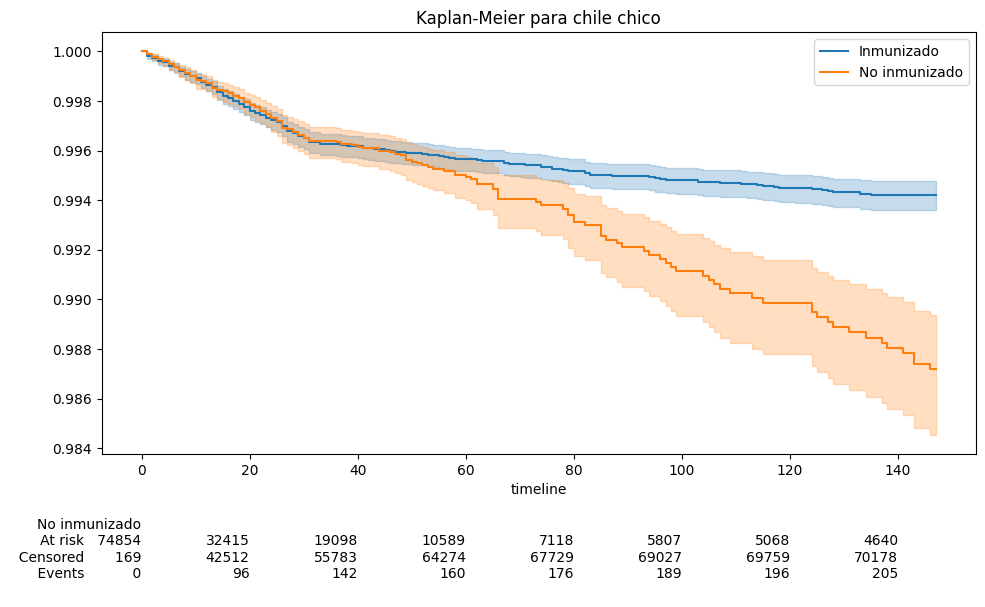

         test_statistic         p   -log2(p)
0.0 1.0       13.099811  0.000295  11.725406




,who,p_value
0,chile_chico,0.0


In [10]:
resultados_log_rank = []
d_reg = df_mayer_vrs.query('chile_chico_1  == 1')
d_reg_agg = (
    d_reg[['RUN','event_vrs', 'duration', 'inmunizado']]
    .groupby(['RUN', 'inmunizado', 'event_vrs'], as_index=False) 
    .agg({'duration': 'sum'}) 
)

T = d_reg_agg["duration"]  
E = d_reg_agg["event_vrs"]  
inmunizado = d_reg_agg["inmunizado"]  

print("INMUNE, NO INMUNE")
print('MAXIMO TIEMPO:', T[inmunizado == 1].max(), T[inmunizado == 0].max())
print('MEDIA TIEMPO:', T[inmunizado == 1].mean(), T[inmunizado == 0].mean())

plt.figure(figsize=(10, 6))  
ax = plt.subplot(111)

kmf = KaplanMeierFitter()

#kmf.fit(T, event_observed=E, label="General")
#kmf.plot_survival_function(ax=ax)

kmf.fit(T[inmunizado == 1], event_observed=E[inmunizado == 1], timeline=t, label="Inmunizado")
kmf.plot_survival_function(ax=ax)

kmf.fit(T[inmunizado == 0], event_observed=E[inmunizado == 0], timeline=t, label="No inmunizado")
kmf.plot_survival_function(ax=ax)

add_at_risk_counts(kmf, ax=ax)

plt.tight_layout()
plt.title(f'Kaplan-Meier para chile chico')
plt.show()

log_rank = pairwise_logrank_test(T, inmunizado, E)
print(log_rank.summary)
print('\n')

p_value = round(log_rank.p_value[0],3) 
#test_stat = log_rank.test_statistic[0]  

resultados_log_rank.append({
    'who': "chile_chico",
    'p_value': p_value #,'test_statistic': test_stat
})

# Convertir la lista de resultados en un DataFrame
df_log_rank = pd.DataFrame(resultados_log_rank)

# Mostrar el DataFrame final con los resultados
display(df_log_rank)

INMUNE, NO INMUNE
MAXIMO TIEMPO: 147.0 147.0
MEDIA TIEMPO: 96.60757851423658 30.662022221128126


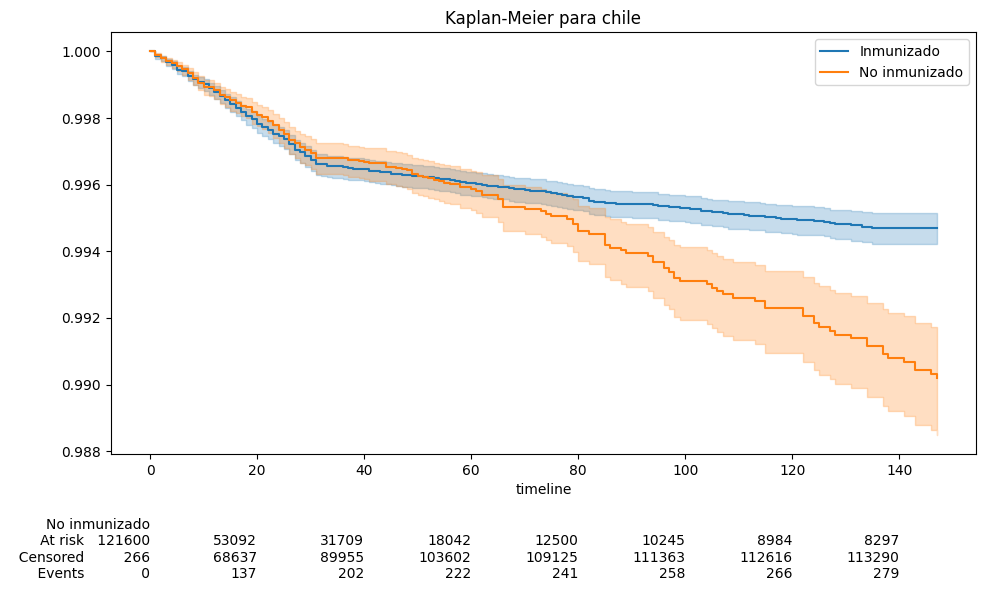

         test_statistic         p  -log2(p)
0.0 1.0        7.259758  0.007052  7.147817




,who,p_value
0,todo chile,0.007


In [73]:
resultados_log_rank = []
d_reg = df_mayer_vrs
d_reg_agg = (
    d_reg[['RUN','event_vrs', 'duration', 'inmunizado']]
    .groupby(['RUN', 'inmunizado', 'event_vrs'], as_index=False) 
    .agg({'duration': 'sum'}) 
)

T = d_reg_agg["duration"]  
E = d_reg_agg["event_vrs"]  
inmunizado = d_reg_agg["inmunizado"]  

print("INMUNE, NO INMUNE")
print('MAXIMO TIEMPO:', T[inmunizado == 1].max(), T[inmunizado == 0].max())
print('MEDIA TIEMPO:', T[inmunizado == 1].mean(), T[inmunizado == 0].mean())

plt.figure(figsize=(10, 6))  
ax = plt.subplot(111)

kmf = KaplanMeierFitter()

#kmf.fit(T, event_observed=E, label="General")
#kmf.plot_survival_function(ax=ax)

kmf.fit(T[inmunizado == 1], event_observed=E[inmunizado == 1], timeline=t, label="Inmunizado")
kmf.plot_survival_function(ax=ax)

kmf.fit(T[inmunizado == 0], event_observed=E[inmunizado == 0], timeline=t, label="No inmunizado")
kmf.plot_survival_function(ax=ax)

add_at_risk_counts(kmf, ax=ax)

plt.tight_layout()
plt.title(f'Kaplan-Meier para chile')
plt.show()

log_rank = pairwise_logrank_test(T, inmunizado, E)
print(log_rank.summary)
print('\n')

p_value = round(log_rank.p_value[0],3) 
#test_stat = log_rank.test_statistic[0]  

resultados_log_rank.append({
    'who': "todo chile",
    'p_value': p_value #,'test_statistic': test_stat
})

# Convertir la lista de resultados en un DataFrame
df_log_rank = pd.DataFrame(resultados_log_rank)

# Mostrar el DataFrame final con los resultados
display(df_log_rank)